# Comprehensive Exam
#  A structured data mining analysis on a real-world dataset.
### By Wasim Raja Mondal

<a id="99"></a>


<b>Program Sections</b>
<ul>
<li><a href = "#0">  Part 1: Data Understanding  </a></li>
<li><a href = "#1"> Part 2: Feature Selection </a></li>
<li><a href = "#2"> Part 3: Supervised Models </a></li> 
<li><a href = "#3"> Part 4: Clustering </a></li> 
<li><a href = "#4"> Part 5: Dimensionality Reduction </a></li>
<li><a href = "#5"> Part 6: Analysis </a></li>

In [1]:
!pip install numpy #installing numpy
!pip install pandas #installing pandas
!pip install matplotlib #installing matplotlib
!pip install seaborn #installing seaborn
!pip install scikit-learn #installing scikit learn
import numpy as np  #importing numpy
import pandas as pd #importing pandas
import seaborn as sns #importing seaborn
import pandas as pd #importing pandas
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500) #allows for up to 500 columns to be displayed when viewing a dataframe
plt.style.use("seaborn-v0_8-whitegrid") ##a style that can be used for plots
import datetime as dt #importing datetime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Part 1: Data Understanding

### loading all the table

In [2]:
df_kcal = pd.read_csv('data/Food_Supply_kcal_Data.csv', index_col=None, header=0)
df_kcal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       170 non-null    object 
 1   Alcoholic Beverages           170 non-null    float64
 2   Animal Products               170 non-null    float64
 3   Animal fats                   170 non-null    float64
 4   Aquatic Products, Other       170 non-null    float64
 5   Cereals - Excluding Beer      170 non-null    float64
 6   Eggs                          170 non-null    float64
 7   Fish, Seafood                 170 non-null    float64
 8   Fruits - Excluding Wine       170 non-null    float64
 9   Meat                          170 non-null    float64
 10  Milk - Excluding Butter       170 non-null    float64
 11  Miscellaneous                 170 non-null    float64
 12  Offals                        170 non-null    float64
 13  Oilcr

In [3]:
df_kcal.head()

,Country,Alcoholic Beverages,Animal Products,Animal fats,"Aquatic Products, Other",Cereals - Excluding Beer,Eggs,"Fish, Seafood",Fruits - Excluding Wine,Meat,Milk - Excluding Butter,Miscellaneous,Offals,Oilcrops,Pulses,Spices,Starchy Roots,Stimulants,Sugar Crops,Sugar & Sweeteners,Treenuts,Vegetal Products,Vegetable Oils,Vegetables,Obesity,Undernourished,Confirmed,Deaths,Recovered,Active,Population,Unit (all except Population)
0,Afghanistan,0.0000,4.7774,0.8504,0.0,37.1186,0.1501,0.0000,1.4757,1.2006,2.4512,0.0250,0.1251,0.1751,0.5003,0.1001,0.3252,0.0750,0.0,2.2261,0.1251,45.2476,2.3012,0.7504,4.5,29.8,0.142134,0.006186,0.123374,0.012574,38928000.0,%
1,Albania,0.9120,16.0930,1.0591,0.0,16.2107,0.8091,0.1471,3.8982,3.8688,9.9441,0.0588,0.2648,1.0886,0.8091,0.0000,1.2651,0.2501,0.0,3.4422,0.3972,33.9070,2.8244,2.7508,22.3,6.2,2.967301,0.050951,1.792636,1.123714,2838000.0,%
2,Algeria,0.0896,6.0326,0.1941,0.0,25.0112,0.4181,0.1195,3.1805,1.2543,3.9869,0.1045,0.0597,0.2688,1.0900,0.1195,1.9262,0.1493,0.0,3.9869,0.2240,43.9749,5.7638,2.0457,26.6,3.9,0.244897,0.006558,0.167572,0.070767,44357000.0,%
3,Angola,1.9388,4.6927,0.2644,0.0,18.3521,0.0441,0.8372,2.3133,2.9302,0.5067,0.0661,0.1102,1.0795,1.4981,0.0000,12.6239,0.0441,0.0,2.7539,0.0000,45.3184,4.2741,0.3525,6.8,25,0.061687,0.001461,0.056808,0.003419,32522000.0,%
4,Antigua and Barbuda,2.3041,15.3672,1.5429,0.0,13.7215,0.2057,1.7280,3.6824,7.0356,4.6904,0.3086,0.1646,0.5966,0.4526,0.3497,0.8434,0.4937,0.0,5.8218,0.0823,34.6225,4.6904,1.2960,19.1,NaN,0.293878,0.007143,0.190816,0.095918,98000.0,%


In [4]:
df_fat = pd.read_csv('data/Fat_Supply_Quantity_Data.csv', index_col=None, header=0)
df_fat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       170 non-null    object 
 1   Alcoholic Beverages           170 non-null    float64
 2   Animal Products               170 non-null    float64
 3   Animal fats                   170 non-null    float64
 4   Aquatic Products, Other       170 non-null    float64
 5   Cereals - Excluding Beer      170 non-null    float64
 6   Eggs                          170 non-null    float64
 7   Fish, Seafood                 170 non-null    float64
 8   Fruits - Excluding Wine       170 non-null    float64
 9   Meat                          170 non-null    float64
 10  Miscellaneous                 170 non-null    float64
 11  Milk - Excluding Butter       170 non-null    float64
 12  Offals                        170 non-null    float64
 13  Oilcr

In [5]:
df_fat.head()

,Country,Alcoholic Beverages,Animal Products,Animal fats,"Aquatic Products, Other",Cereals - Excluding Beer,Eggs,"Fish, Seafood",Fruits - Excluding Wine,Meat,Miscellaneous,Milk - Excluding Butter,Offals,Oilcrops,Pulses,Spices,Starchy Roots,Stimulants,Sugar Crops,Sugar & Sweeteners,Treenuts,Vegetal Products,Vegetable Oils,Vegetables,Obesity,Undernourished,Confirmed,Deaths,Recovered,Active,Population,Unit (all except Population)
0,Afghanistan,0.0,21.6397,6.2224,0.0,8.0353,0.6859,0.0327,0.4246,6.1244,0.0163,8.2803,0.3103,1.0452,0.1960,0.2776,0.0490,0.0980,0.0,0.0,0.7513,28.3684,17.0831,0.3593,4.5,29.8,0.142134,0.006186,0.123374,0.012574,38928000.0,%
1,Albania,0.0,32.0002,3.4172,0.0,2.6734,1.6448,0.1445,0.6418,8.7428,0.0170,17.7576,0.2933,3.1622,0.1148,0.0000,0.0510,0.5270,0.0,0.0,0.9181,17.9998,9.2443,0.6503,22.3,6.2,2.967301,0.050951,1.792636,1.123714,2838000.0,%
2,Algeria,0.0,14.4175,0.8972,0.0,4.2035,1.2171,0.2008,0.5772,3.8961,0.0439,8.0934,0.1067,1.1983,0.2698,0.1568,0.1129,0.2886,0.0,0.0,0.8595,35.5857,27.3606,0.5145,26.6,3.9,0.244897,0.006558,0.167572,0.070767,44357000.0,%
3,Angola,0.0,15.3041,1.3130,0.0,6.5545,0.1539,1.4155,0.3488,11.0268,0.0308,1.2309,0.1539,3.9902,0.3282,0.0103,0.7078,0.1128,0.0,0.0,0.0308,34.7010,22.4638,0.1231,6.8,25,0.061687,0.001461,0.056808,0.003419,32522000.0,%
4,Antigua and Barbuda,0.0,27.7033,4.6686,0.0,3.2153,0.3872,1.5263,1.2177,14.3202,0.0898,6.6607,0.1347,1.3579,0.0673,0.3591,0.0449,1.0549,0.0,0.0,0.2020,22.2995,14.4436,0.2469,19.1,NaN,0.293878,0.007143,0.190816,0.095918,98000.0,%


In [6]:
df_protein = pd.read_csv('data/Protein_Supply_Quantity_Data.csv', index_col=None, header=0)
df_protein.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       170 non-null    object 
 1   Alcoholic Beverages           170 non-null    float64
 2   Animal Products               170 non-null    float64
 3   Animal fats                   170 non-null    float64
 4   Aquatic Products, Other       170 non-null    float64
 5   Cereals - Excluding Beer      170 non-null    float64
 6   Eggs                          170 non-null    float64
 7   Fish, Seafood                 170 non-null    float64
 8   Fruits - Excluding Wine       170 non-null    float64
 9   Meat                          170 non-null    float64
 10  Milk - Excluding Butter       170 non-null    float64
 11  Offals                        170 non-null    float64
 12  Oilcrops                      170 non-null    float64
 13  Pulse

In [7]:
df_protein.head()

,Country,Alcoholic Beverages,Animal Products,Animal fats,"Aquatic Products, Other",Cereals - Excluding Beer,Eggs,"Fish, Seafood",Fruits - Excluding Wine,Meat,Milk - Excluding Butter,Offals,Oilcrops,Pulses,Spices,Starchy Roots,Stimulants,Sugar Crops,Sugar & Sweeteners,Treenuts,Vegetal Products,Vegetable Oils,Vegetables,Miscellaneous,Obesity,Undernourished,Confirmed,Deaths,Recovered,Active,Population,Unit (all except Population)
0,Afghanistan,0.0000,9.7523,0.0277,0.0,35.9771,0.4067,0.0647,0.5824,3.1337,5.5278,0.5916,0.2034,1.2479,0.1664,0.1941,0.5546,0.0,0.0000,0.1387,40.2477,0.0000,1.1370,0.0462,4.5,29.8,0.142134,0.006186,0.123374,0.012574,38928000.0,%
1,Albania,0.1840,27.7469,0.0711,0.0,14.2331,1.8069,0.6274,1.2757,7.6582,16.4750,1.1084,0.3722,1.4555,0.0000,0.8867,0.2635,0.0,0.0042,0.2677,22.2552,0.0084,3.2456,0.0544,22.3,6.2,2.967301,0.050951,1.792636,1.123714,2838000.0,%
2,Algeria,0.0323,13.8360,0.0054,0.0,26.5633,1.2916,0.6350,1.1624,3.5088,8.0616,0.3283,0.1830,2.5509,0.1776,1.4638,0.4628,0.0,0.0000,0.2745,36.1694,0.0269,3.1267,0.1399,26.6,3.9,0.244897,0.006558,0.167572,0.070767,44357000.0,%
3,Angola,0.6285,15.2311,0.0277,0.0,20.3882,0.1756,5.4436,1.2754,7.6248,1.1460,0.8133,2.1534,4.0850,0.0000,5.1941,0.1017,0.0,0.0092,0.0092,34.7782,0.0092,0.8133,0.0924,6.8,25,0.061687,0.001461,0.056808,0.003419,32522000.0,%
4,Antigua and Barbuda,0.1535,33.1901,0.1289,0.0,10.5108,0.4850,8.2146,1.2586,16.0670,7.4349,0.8534,0.7674,0.8841,0.3438,0.4666,0.4113,0.0,0.0000,0.0737,16.8161,0.0430,1.6024,0.2947,19.1,NaN,0.293878,0.007143,0.190816,0.095918,98000.0,%


In [8]:
df_kg = pd.read_csv('data/Food_Supply_Quantity_kg_Data.csv', index_col=None, header=0)
df_kg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       170 non-null    object 
 1   Alcoholic Beverages           170 non-null    float64
 2   Animal fats                   170 non-null    float64
 3   Animal Products               170 non-null    float64
 4   Aquatic Products, Other       170 non-null    float64
 5   Cereals - Excluding Beer      170 non-null    float64
 6   Eggs                          170 non-null    float64
 7   Fish, Seafood                 170 non-null    float64
 8   Fruits - Excluding Wine       170 non-null    float64
 9   Meat                          170 non-null    float64
 10  Milk - Excluding Butter       170 non-null    float64
 11  Miscellaneous                 170 non-null    float64
 12  Offals                        170 non-null    float64
 13  Oilcr

### predict the common feature from these dataframes

In [9]:
df_merged=pd.concat([df_kcal,df_fat,df_protein,df_kg], axis=1)

In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Columns: 128 entries, Country to Unit (all except Population)
dtypes: float64(116), object(12)
memory usage: 170.1+ KB


In [11]:
# Keep the first instance of each column name
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()].copy()

In [12]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       170 non-null    object 
 1   Alcoholic Beverages           170 non-null    float64
 2   Animal Products               170 non-null    float64
 3   Animal fats                   170 non-null    float64
 4   Aquatic Products, Other       170 non-null    float64
 5   Cereals - Excluding Beer      170 non-null    float64
 6   Eggs                          170 non-null    float64
 7   Fish, Seafood                 170 non-null    float64
 8   Fruits - Excluding Wine       170 non-null    float64
 9   Meat                          170 non-null    float64
 10  Milk - Excluding Butter       170 non-null    float64
 11  Miscellaneous                 170 non-null    float64
 12  Offals                        170 non-null    float64
 13  Oilcr

- As we observe from the above info, most of columns has 170 entries. Howvever, few columns has fewer than 170
- This suggests that the present dataset has missing values. So, we will remove all these missing values

In [13]:
df_merged = df_merged.dropna()

In [14]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       154 non-null    object 
 1   Alcoholic Beverages           154 non-null    float64
 2   Animal Products               154 non-null    float64
 3   Animal fats                   154 non-null    float64
 4   Aquatic Products, Other       154 non-null    float64
 5   Cereals - Excluding Beer      154 non-null    float64
 6   Eggs                          154 non-null    float64
 7   Fish, Seafood                 154 non-null    float64
 8   Fruits - Excluding Wine       154 non-null    float64
 9   Meat                          154 non-null    float64
 10  Milk - Excluding Butter       154 non-null    float64
 11  Miscellaneous                 154 non-null    float64
 12  Offals                        154 non-null    float64
 13  Oilcrops  

- Now we observe that all the columns have equa entries i.e. 154. So, all there is no more missing vlues in the dataset 

-To investiugate the outlier, we will visulaize some inportant feature

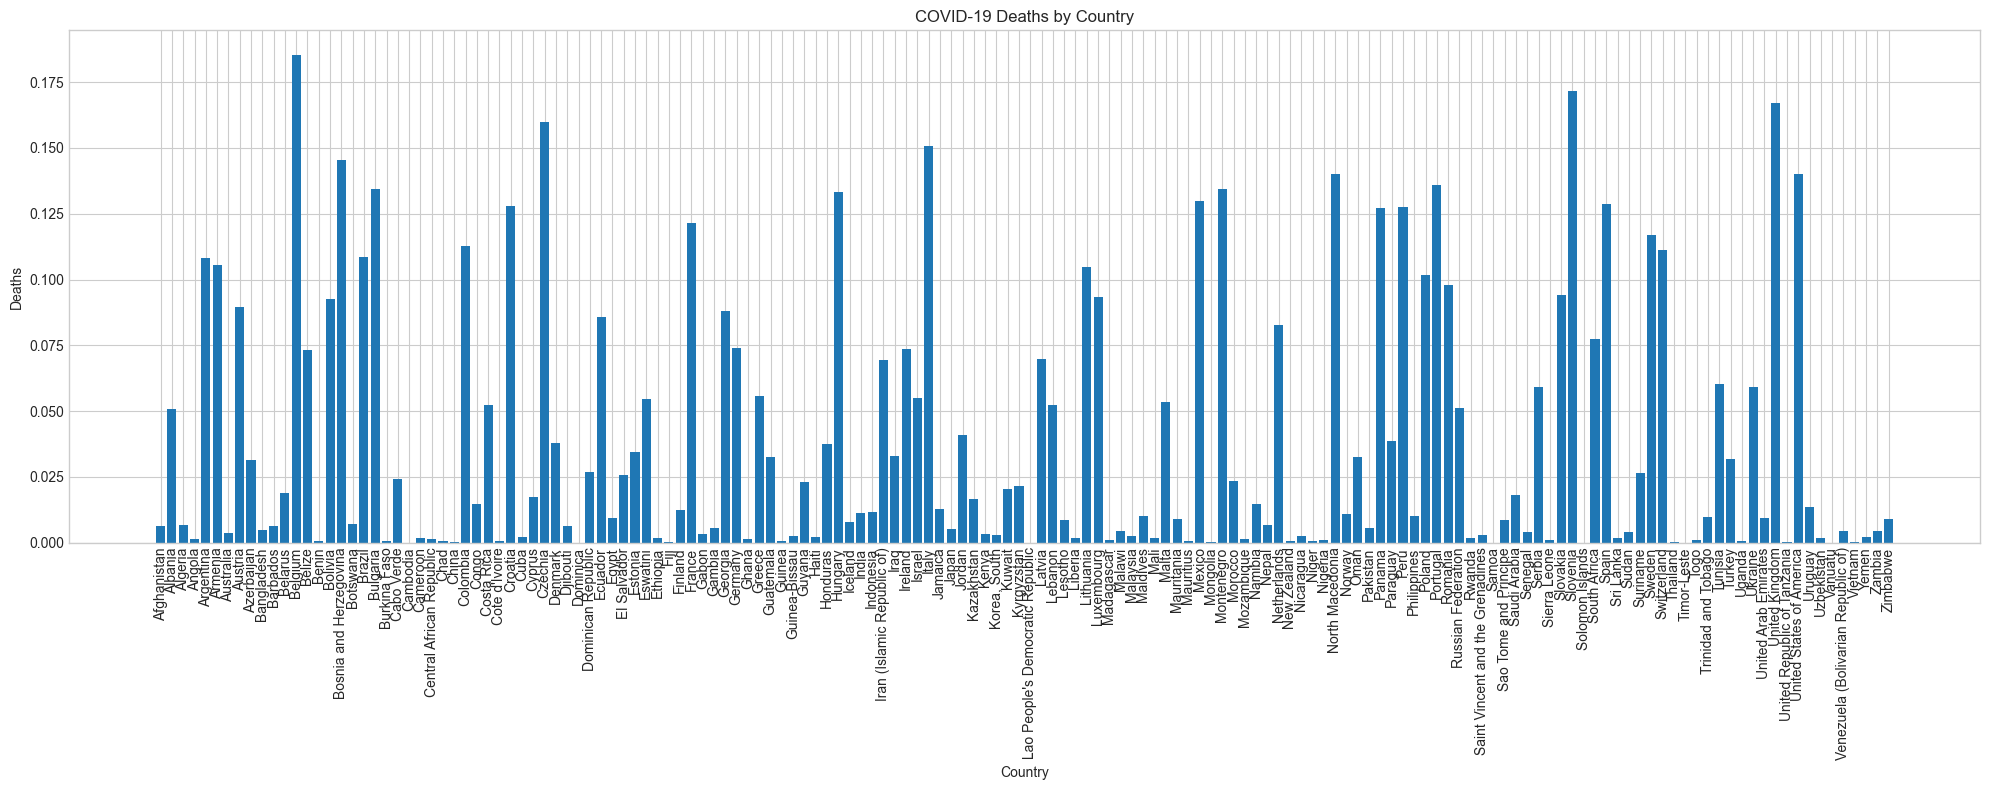

In [15]:
plt.figure(figsize=(20,8))

plt.bar(df_merged['Country'], df_merged['Deaths'])

plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Deaths")
plt.title("COVID-19 Deaths by Country")

plt.tight_layout()
plt.show()

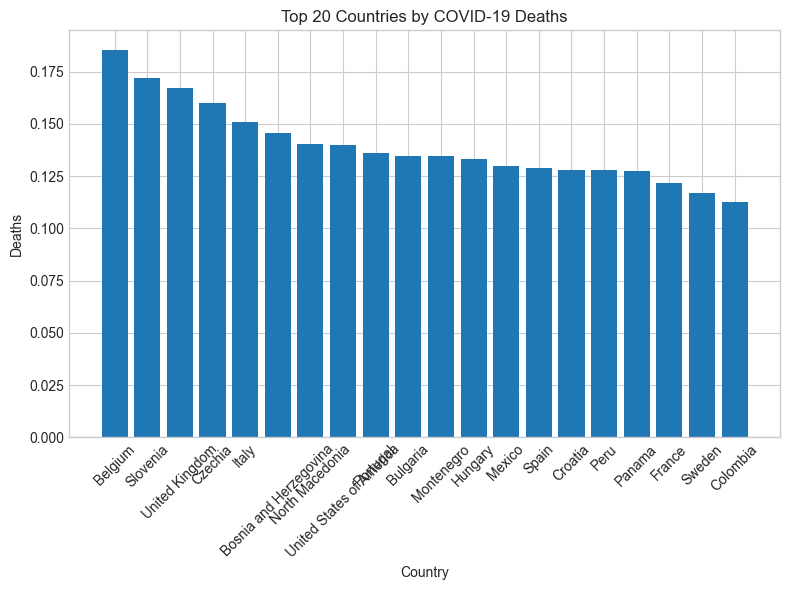

In [16]:
top20 = df_merged.sort_values(by='Deaths', ascending=False).head(20)

plt.figure(figsize=(8,6))

plt.bar(top20['Country'], top20['Deaths'])

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Deaths")
plt.title("Top 20 Countries by COVID-19 Deaths")

plt.tight_layout()
plt.show()

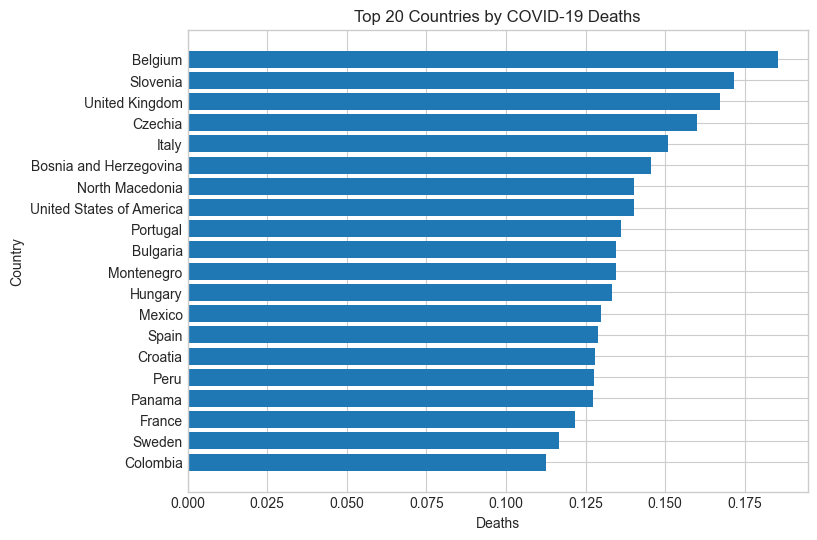

In [17]:
top20 = df_merged.sort_values(by='Deaths', ascending=True).tail(20)

plt.figure(figsize=(8,6))

plt.barh(top20['Country'], top20['Deaths'])

plt.xlabel("Deaths")
plt.ylabel("Country")
plt.title("Top 20 Countries by COVID-19 Deaths")

#plt.savefig(
#    "deathbar.png",
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()

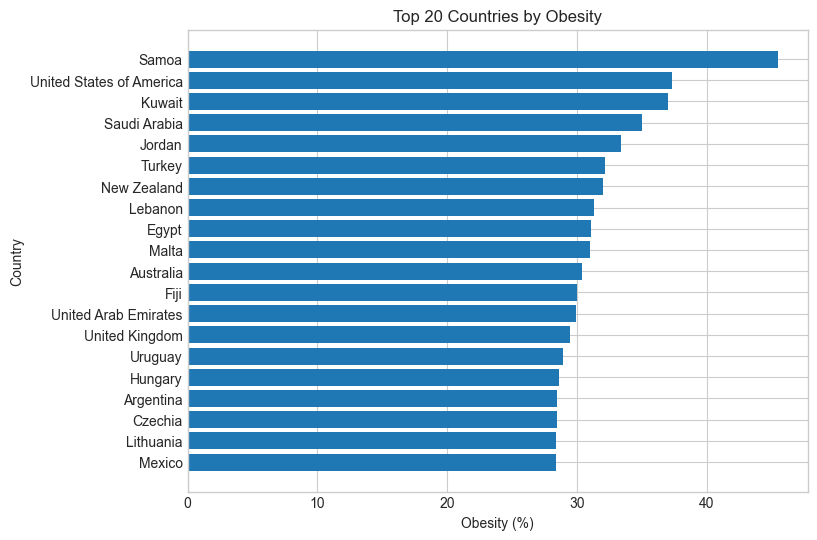

In [18]:
top20_obesity = df_merged.sort_values(
    by='Obesity',
    ascending=True
).tail(20)

plt.figure(figsize=(8,6))

plt.barh(top20_obesity['Country'], top20_obesity['Obesity'])

plt.xlabel("Obesity (%)")
plt.ylabel("Country")
plt.title("Top 20 Countries by Obesity")

#plt.savefig(  "obesity.png",dpi=300,bbox_inches='tight')


plt.show()

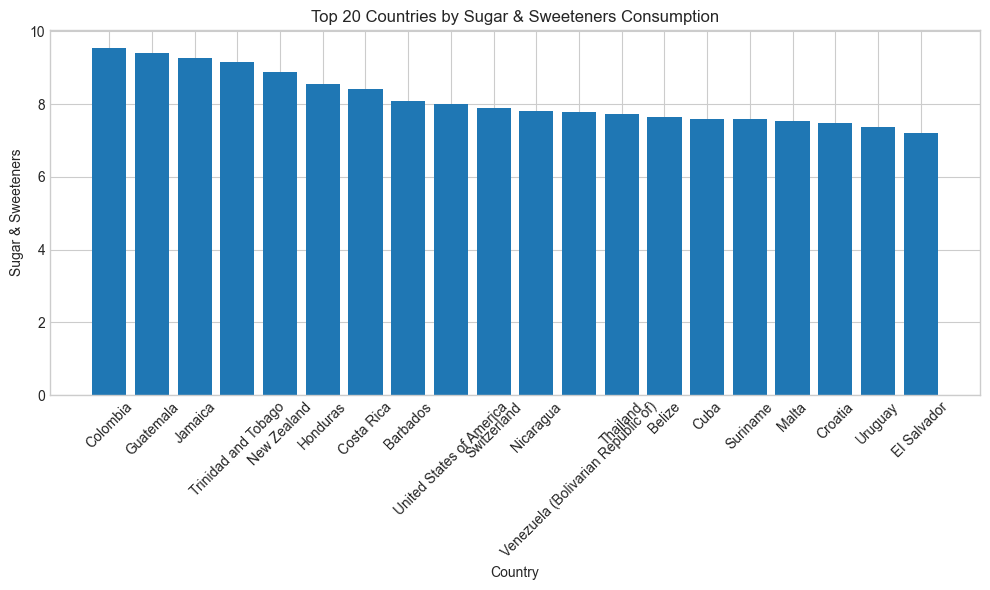

In [19]:
top20_sugar = df_merged.sort_values(
    by='Sugar & Sweeteners',
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

plt.bar(top20_sugar['Country'], top20_sugar['Sugar & Sweeteners'])

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Sugar & Sweeteners")
plt.title("Top 20 Countries by Sugar & Sweeteners Consumption")

plt.tight_layout()
#plt.savefig("sugar.png",dpi=300,bbox_inches='tight')

plt.show()

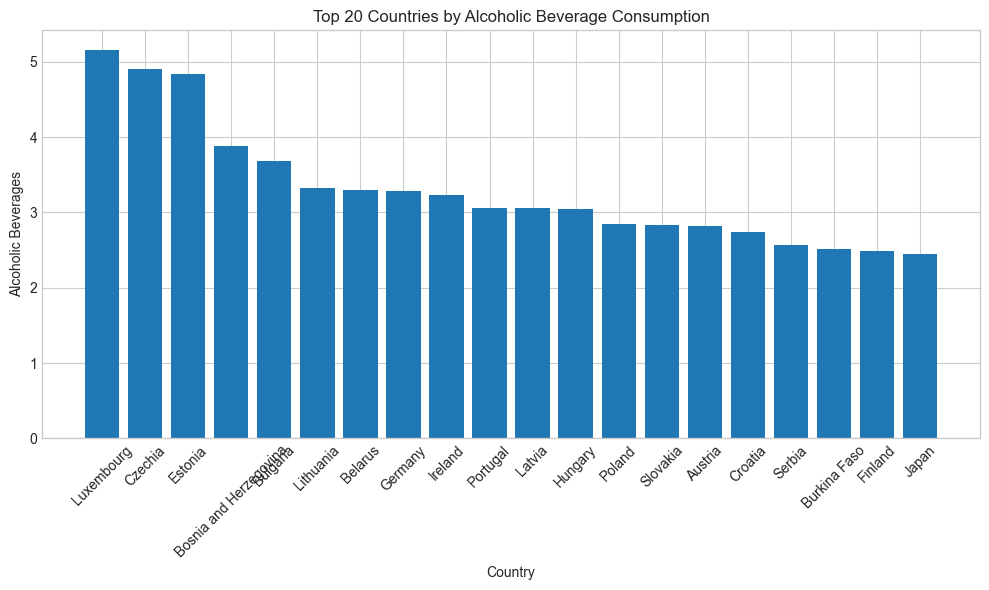

In [20]:
top20_alcohol = df_merged.sort_values(
    by='Alcoholic Beverages',
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

plt.bar(top20_alcohol['Country'], top20_alcohol['Alcoholic Beverages'])

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Alcoholic Beverages")
plt.title("Top 20 Countries by Alcoholic Beverage Consumption")

plt.tight_layout()

#plt.savefig("alchol.png",dpi=300,bbox_inches='tight')

plt.show()

In [22]:
important_cols = [
    'Obesity',
    'Deaths',
    'Alcoholic Beverages',
    'Sugar & Sweeteners',
    'Animal Products',
    'Vegetables',
    'Population'
]

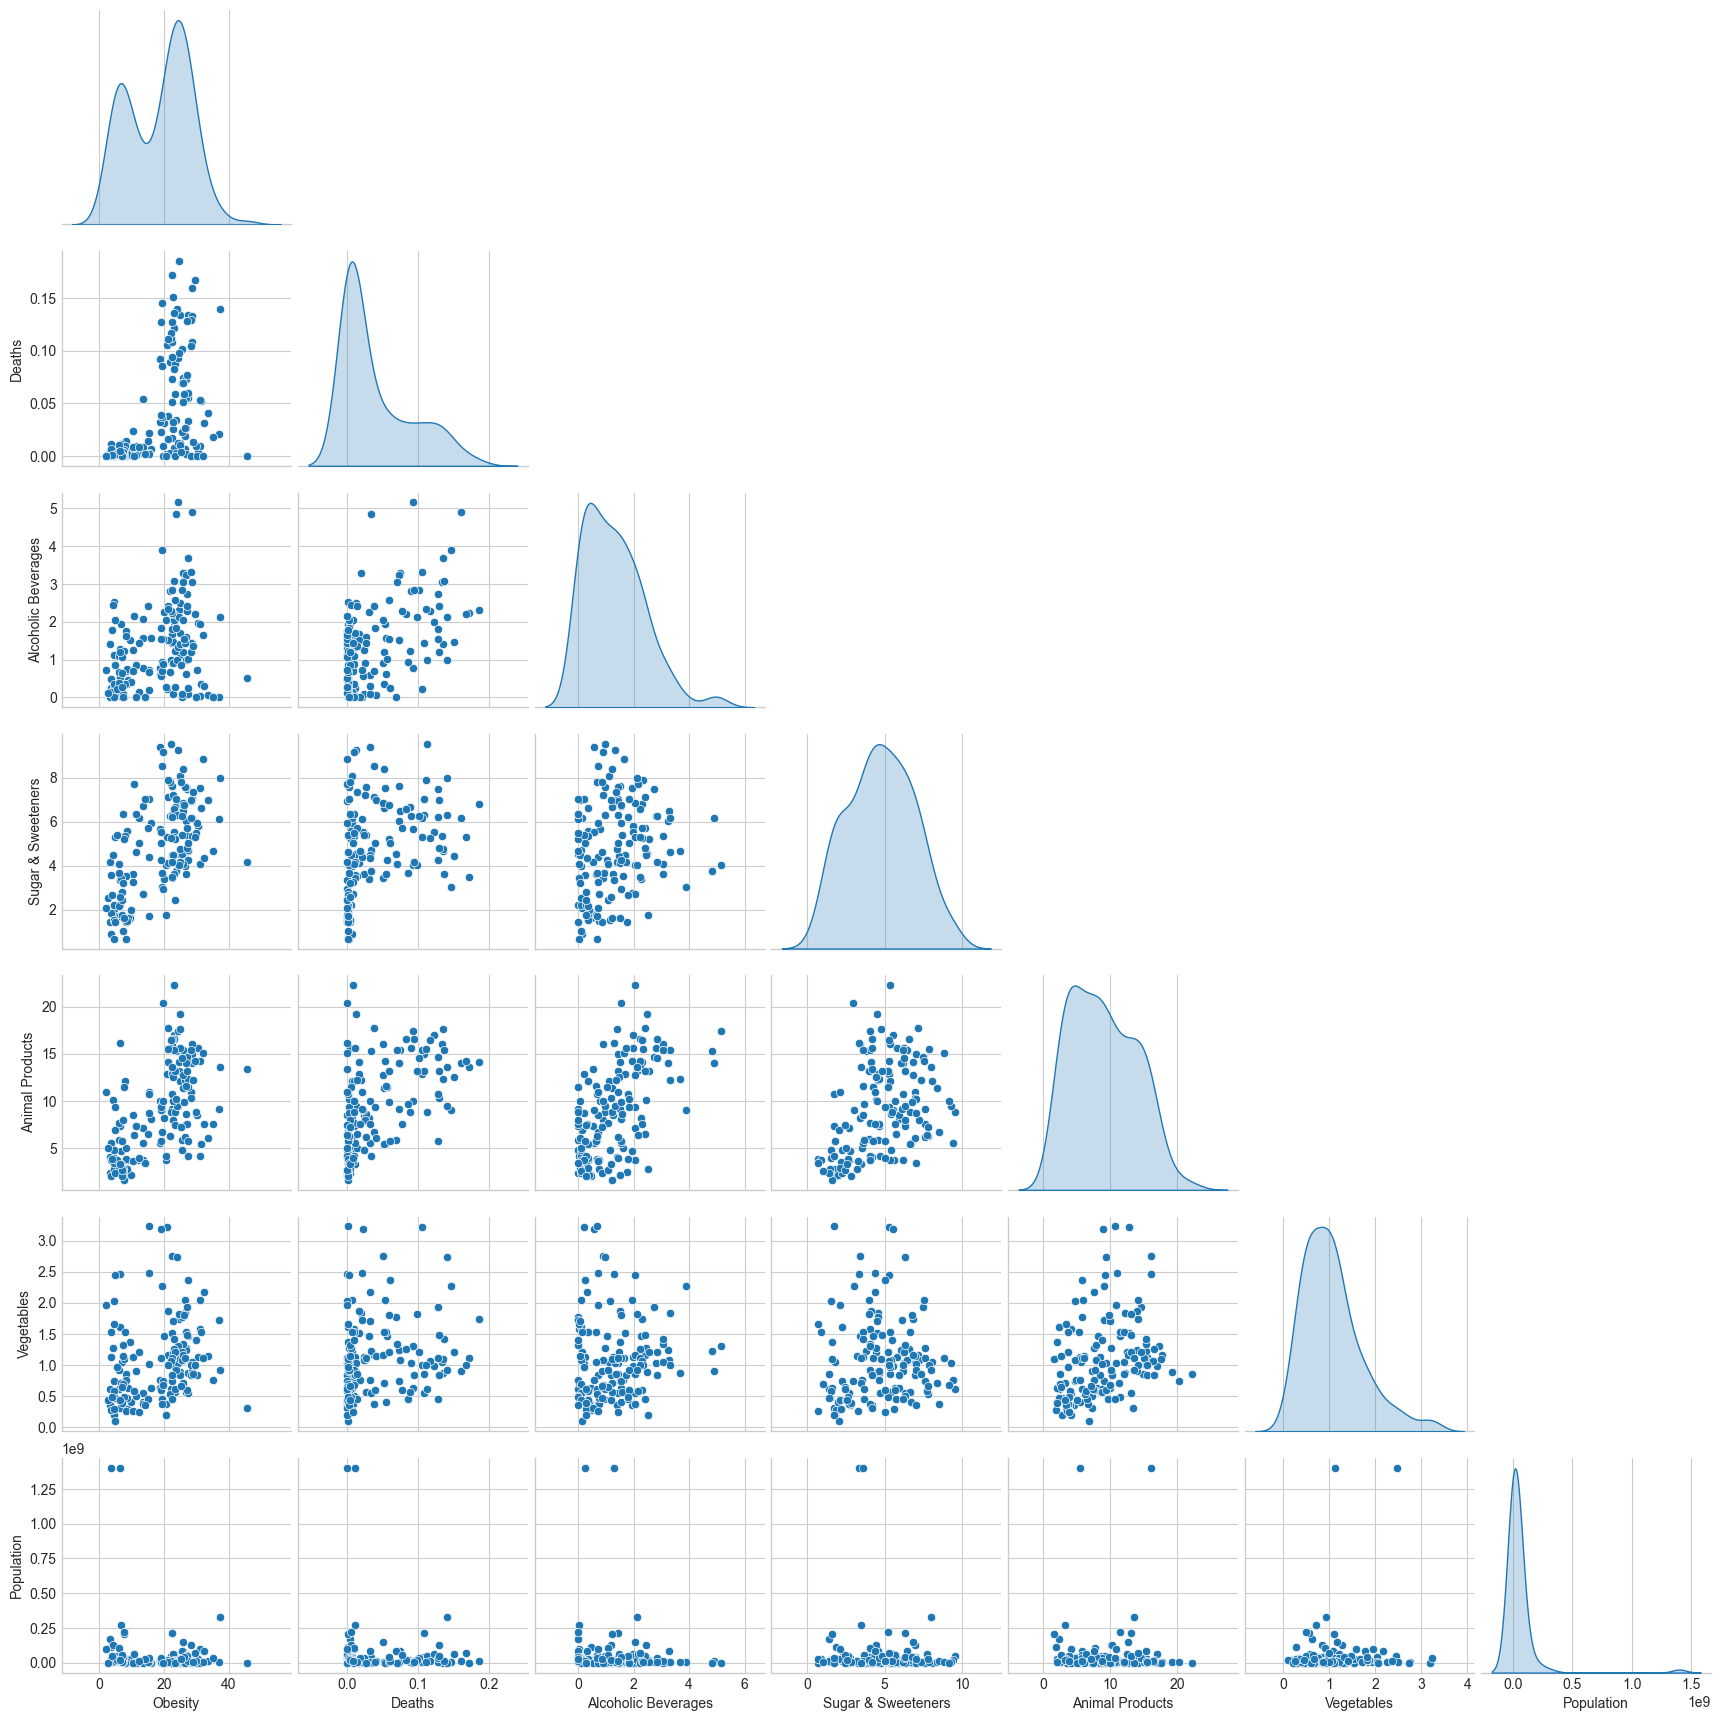

In [23]:
sns.pairplot(
    df_merged[important_cols],
    diag_kind='kde',
    corner=True
)
#plt.savefig("pairplot.png",dpi=300,bbox_inches='tight')

plt.show()

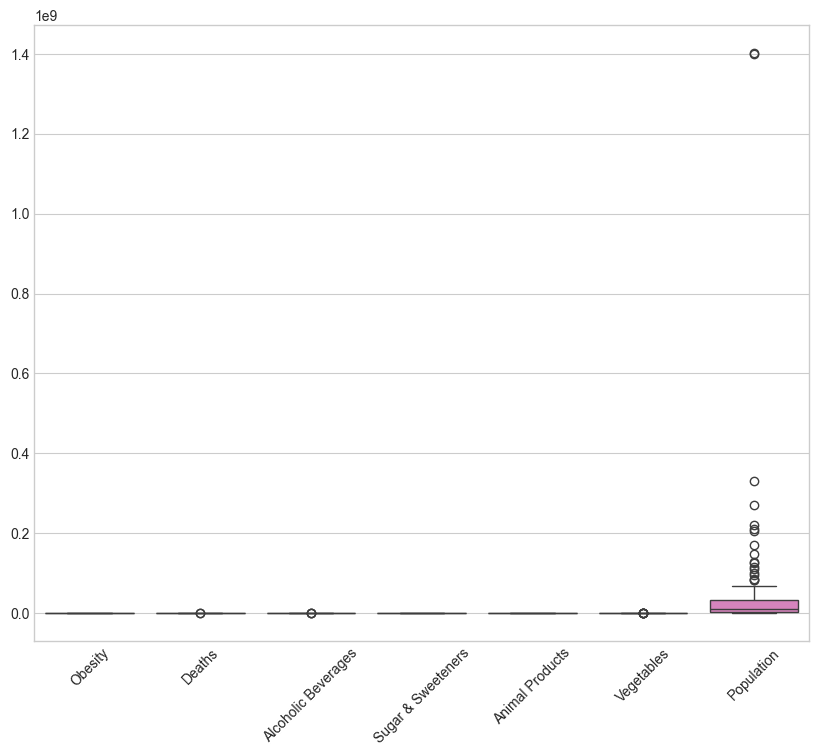

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.boxplot(data=df_merged[important_cols])

plt.xticks(rotation=45)

#plt.savefig("boxplot_important_columns.png",dpi=300,bbox_inches='tight')

plt.show()

- Population Has Extreme Outliers: Population is heavily right-skewed. A few countries have extremely large populations compared to the rest. (China / India / USA). Boxplot shows many extreme outliers. Pairplot diagonal KDE shows very sharp skew.
- Deaths Are Right-Skewed / Outlier Heavy. Most countries have very low death values. Few countries have significantly larger deaths.
- Positive Correlation Between Obesity and Animal Products: Countries with higher animal product consumption tend to have higher obesity.
- Positive Trend Between Sugar and Obesity: Increased sugar/sweetener intake may contribute to obesity.
- Alcohol Shows Weak/Moderate Positive Correlation with Obesity. Alcoholic beverage consumption may weakly associate with obesity.
- Possible Relationship Between Deaths and Obesity. Higher obesity countries appear somewhat associated with higher deaths.

Pairwise scatterplots and boxplots were generated to examine the distributions, relationships, and potential outliers among important variables. The analysis revealed that Population and Deaths exhibit substantial right-skewness and contain extreme outliers, indicating the presence of countries with disproportionately large populations and COVID mortality. Additionally, moderate positive correlations were observed between Obesity and Animal Product consumption, as well as between Sugar & Sweeteners and Obesity, suggesting potential dietary influences on obesity prevalence. Most variables displayed non-normal distributions, motivating the use of feature scaling and transformation during preprocessing.

Log transform skewed variables:

In [25]:
df_merged['Population'] = np.log1p(df_merged['Population'])
df_merged['Deaths'] = np.log1p(df_merged['Deaths'])

Then standardize all features:

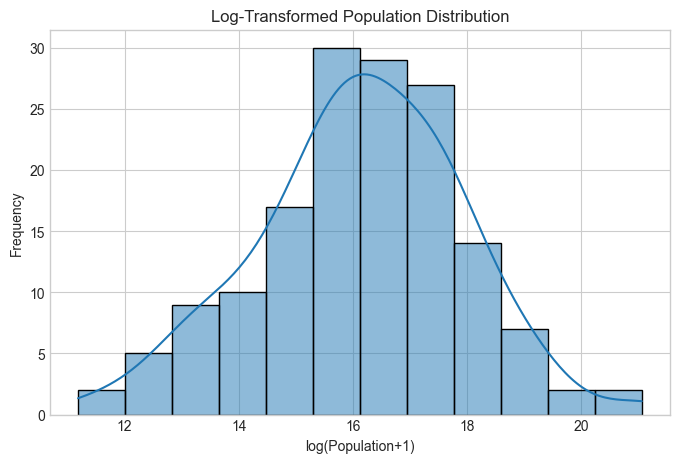

In [26]:
import numpy as np


plt.figure(figsize=(8,5))

sns.histplot(df_merged['Population'], kde=True)

plt.title("Log-Transformed Population Distribution")
plt.xlabel("log(Population+1)")
plt.ylabel("Frequency")

plt.show()

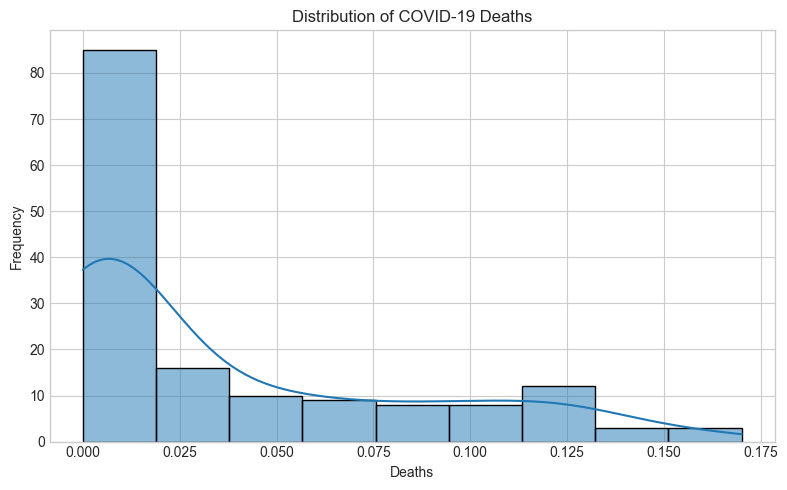

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_merged['Deaths'], kde=True)

plt.title("Distribution of COVID-19 Deaths")
plt.xlabel("Deaths")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Investigating feature type: numerical vs catagorical 

In [28]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       154 non-null    object 
 1   Alcoholic Beverages           154 non-null    float64
 2   Animal Products               154 non-null    float64
 3   Animal fats                   154 non-null    float64
 4   Aquatic Products, Other       154 non-null    float64
 5   Cereals - Excluding Beer      154 non-null    float64
 6   Eggs                          154 non-null    float64
 7   Fish, Seafood                 154 non-null    float64
 8   Fruits - Excluding Wine       154 non-null    float64
 9   Meat                          154 non-null    float64
 10  Milk - Excluding Butter       154 non-null    float64
 11  Miscellaneous                 154 non-null    float64
 12  Offals                        154 non-null    float64
 13  Oilcrops  

preprocess the data for catagorical values 

In [29]:
df_merged['Undernourished'].head(50)

0     29.8
1      6.2
2      3.9
3       25
5      4.6
6      4.3
7     <2.5
8     <2.5
9     <2.5
11    14.7
12     3.9
13    <2.5
14    <2.5
15     7.5
16    10.1
17    17.1
18    <2.5
19    26.4
20    <2.5
21     3.6
22      20
23    12.6
24    16.4
25     9.9
27    59.6
28    37.5
30     8.5
31     4.8
32    40.3
33     4.8
34      19
35    <2.5
36    <2.5
37     5.6
38    <2.5
39    <2.5
40    18.9
41     6.2
42     9.5
43     7.9
44     4.5
45       9
46     2.9
47    20.6
48    20.6
49     3.7
50    <2.5
51    <2.5
53    10.5
54    10.2
Name: Undernourished, dtype: object

In [30]:
df_merged['Undernourished'] = (
    df_merged['Undernourished']
    .astype(str)
    .str.replace('<2.5', '2.5')
    .astype(float)
)

In [31]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       154 non-null    object 
 1   Alcoholic Beverages           154 non-null    float64
 2   Animal Products               154 non-null    float64
 3   Animal fats                   154 non-null    float64
 4   Aquatic Products, Other       154 non-null    float64
 5   Cereals - Excluding Beer      154 non-null    float64
 6   Eggs                          154 non-null    float64
 7   Fish, Seafood                 154 non-null    float64
 8   Fruits - Excluding Wine       154 non-null    float64
 9   Meat                          154 non-null    float64
 10  Milk - Excluding Butter       154 non-null    float64
 11  Miscellaneous                 154 non-null    float64
 12  Offals                        154 non-null    float64
 13  Oilcrops  

In [32]:
df_merged['Unit (all except Population)'].head(20)

0     %
1     %
2     %
3     %
5     %
6     %
7     %
8     %
9     %
11    %
12    %
13    %
14    %
15    %
16    %
17    %
18    %
19    %
20    %
21    %
Name: Unit (all except Population), dtype: object

In [33]:
df_merged = df_merged.drop(
    columns=['Unit (all except Population)']
)

In [34]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   154 non-null    object 
 1   Alcoholic Beverages       154 non-null    float64
 2   Animal Products           154 non-null    float64
 3   Animal fats               154 non-null    float64
 4   Aquatic Products, Other   154 non-null    float64
 5   Cereals - Excluding Beer  154 non-null    float64
 6   Eggs                      154 non-null    float64
 7   Fish, Seafood             154 non-null    float64
 8   Fruits - Excluding Wine   154 non-null    float64
 9   Meat                      154 non-null    float64
 10  Milk - Excluding Butter   154 non-null    float64
 11  Miscellaneous             154 non-null    float64
 12  Offals                    154 non-null    float64
 13  Oilcrops                  154 non-null    float64
 14  Pulses         

In [35]:
df_merged['Country'].head(20)

0                Afghanistan
1                    Albania
2                    Algeria
3                     Angola
5                  Argentina
6                    Armenia
7                  Australia
8                    Austria
9                 Azerbaijan
11                Bangladesh
12                  Barbados
13                   Belarus
14                   Belgium
15                    Belize
16                     Benin
17                   Bolivia
18    Bosnia and Herzegovina
19                  Botswana
20                    Brazil
21                  Bulgaria
Name: Country, dtype: object

In [36]:
df_merged = df_merged.drop(
    columns=['Country']
)

In [37]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Alcoholic Beverages       154 non-null    float64
 1   Animal Products           154 non-null    float64
 2   Animal fats               154 non-null    float64
 3   Aquatic Products, Other   154 non-null    float64
 4   Cereals - Excluding Beer  154 non-null    float64
 5   Eggs                      154 non-null    float64
 6   Fish, Seafood             154 non-null    float64
 7   Fruits - Excluding Wine   154 non-null    float64
 8   Meat                      154 non-null    float64
 9   Milk - Excluding Butter   154 non-null    float64
 10  Miscellaneous             154 non-null    float64
 11  Offals                    154 non-null    float64
 12  Oilcrops                  154 non-null    float64
 13  Pulses                    154 non-null    float64
 14  Spices         

## Part 2: Feature Selection & Engineering 

We are choosing obesity as target variable. 

In [38]:
X = df_merged.drop('Obesity', axis=1)

In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Alcoholic Beverages       154 non-null    float64
 1   Animal Products           154 non-null    float64
 2   Animal fats               154 non-null    float64
 3   Aquatic Products, Other   154 non-null    float64
 4   Cereals - Excluding Beer  154 non-null    float64
 5   Eggs                      154 non-null    float64
 6   Fish, Seafood             154 non-null    float64
 7   Fruits - Excluding Wine   154 non-null    float64
 8   Meat                      154 non-null    float64
 9   Milk - Excluding Butter   154 non-null    float64
 10  Miscellaneous             154 non-null    float64
 11  Offals                    154 non-null    float64
 12  Oilcrops                  154 non-null    float64
 13  Pulses                    154 non-null    float64
 14  Spices         

In [40]:
df_merged['Obesity_Class'] = (
    df_merged['Obesity'] > df_merged['Obesity'].median()
).astype(int)

In [41]:
y = df_merged['Obesity_Class']

In [42]:
y

0      0
1      1
2      1
3      0
5      1
      ..
165    1
166    0
167    0
168    0
169    0
Name: Obesity_Class, Length: 154, dtype: int64

In [43]:
y.value_counts()

Obesity_Class
0    78
1    76
Name: count, dtype: int64

Train/Test split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Feature selection (Variance Threshold)

In [45]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

print("Original:", X_train.shape[1], "Selected:", X_train_var.shape[1])

Original: 29 Selected: 25


### Mutual Information (SelectKBest)

In [46]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(mutual_info_classif, k=10)
X_train_mi = selector.fit_transform(X_train, y_train)
X_test_mi = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("Selected:", X_train_mi.shape[1], " features")
print("Selected features:", list(selected_features))

Selected: 10  features
Selected features: ['Animal Products', 'Animal fats', 'Cereals - Excluding Beer', 'Eggs', 'Sugar & Sweeteners', 'Treenuts', 'Vegetal Products', 'Undernourished', 'Confirmed', 'Active']


### t-test

In [47]:
from scipy.stats import ttest_ind
def ttest_feature_ranking(X, y):
    """
    X: pandas DataFrame
    y: 1D array-like with binary class labels
    returns DataFrame with feature, t_stat, p_value, abs_t
    """
    classes = np.unique(y)
    if len(classes) != 2:
        raise ValueError("T-test demo expects a binary classification problem.")
    
    class0 = classes[0]
    class1 = classes[1]
    
    X0 = X[y == class0]
    X1 = X[y == class1]
    
    results = []
    for col in X.columns:
        t_stat, p_value = ttest_ind(X0[col], X1[col], equal_var=True)
        results.append((col, t_stat, p_value, abs(t_stat)))
    
    results_df = pd.DataFrame(results, columns=["feature", "t_stat", "p_value", "abs_t"])
    results_df = results_df.sort_values("abs_t", ascending=False).reset_index(drop=True)
    return results_df

In [48]:
# Run t-test ranking
ttest_results = ttest_feature_ranking(X_train, y_train)

print("Top 10 features by |t|:")
print(ttest_results.head(10))

# Select top-k features
k = 10
selected_features_ttest = ttest_results["feature"].head(k).tolist()

print("\nNumber of selected features:", len(selected_features_ttest))
print("Selected features:", selected_features_ttest)

# Reduce dataset
X_train_ttest = X_train[selected_features_ttest]
X_test_ttest = X_test[selected_features_ttest]

Top 10 features by |t|:
                    feature    t_stat       p_value     abs_t
0          Vegetal Products  6.334380  6.032517e-09  6.334380
1           Animal Products -6.332502  6.085866e-09  6.332502
2                      Meat -6.193320  1.165526e-08  6.193320
3                 Confirmed -5.952662  3.533033e-08  5.952662
4            Undernourished  5.913132  4.231103e-08  5.913132
5                      Eggs -5.334711  5.541713e-07  5.334711
6                    Deaths -5.223638  8.944409e-07  5.223638
7  Cereals - Excluding Beer  4.965472  2.665213e-06  4.965472
8        Sugar & Sweeteners -4.871157  3.941530e-06  4.871157
9               Animal fats -4.520219  1.627243e-05  4.520219

Number of selected features: 10
Selected features: ['Vegetal Products', 'Animal Products', 'Meat', 'Confirmed', 'Undernourished', 'Eggs', 'Deaths', 'Cereals - Excluding Beer', 'Sugar & Sweeteners', 'Animal fats']


### Chi-square

In [49]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

In [50]:
# Chi-square requires nonnegative features
scaler_chi2 = MinMaxScaler()
X_train_chi2_scaled = scaler_chi2.fit_transform(X_train)
X_test_chi2_scaled = scaler_chi2.transform(X_test)

# Select top-k features by chi-square
k = 10
chi2_selector = SelectKBest(score_func=chi2, k=k)
X_train_chi2 = chi2_selector.fit_transform(X_train_chi2_scaled, y_train)
X_test_chi2 = chi2_selector.transform(X_test_chi2_scaled)

selected_features_chi2 = X_train.columns[chi2_selector.get_support()]

print("Number of selected features:", len(selected_features_chi2))
print("Selected features:", list(selected_features_chi2))

Number of selected features: 10
Selected features: ['Animal Products', 'Animal fats', 'Eggs', 'Meat', 'Starchy Roots', 'Undernourished', 'Confirmed', 'Deaths', 'Recovered', 'Active']


### Recursive Feature Elimination (RFE) (Wrapper Method)

In [51]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

selector = RFE(
    estimator=model,
    n_features_to_select=14
)

X_train_rfe = selector.fit_transform(X_train, y_train)
X_test_rfe = selector.transform(X_test)

selected_features = X.columns[
    selector.get_support()
]

print("Selected features:", list(selected_features))

Selected features: ['Alcoholic Beverages', 'Fish, Seafood', 'Fruits - Excluding Wine', 'Meat', 'Miscellaneous', 'Offals', 'Oilcrops', 'Spices', 'Starchy Roots', 'Sugar & Sweeteners', 'Vegetable Oils', 'Vegetables', 'Undernourished', 'Confirmed']


### L1 Logistic Regression (Embedded)

In [52]:
! pip install ReliefF


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [53]:
from ReliefF import ReliefF
import numpy as np

relief = ReliefF(
    n_neighbors=10
)

relief.fit(X_train.values, y_train.values)

weights = relief.feature_scores

# Top 10 features
selected_idx = np.argsort(weights)[-10:]

selected_features = X_train.columns[selected_idx]

X_train_relief = X_train.iloc[:, selected_idx]
X_test_relief = X_test.iloc[:, selected_idx]

print("Selected features:", list(selected_features))

Selected features: ['Stimulants', 'Offals', 'Eggs', 'Alcoholic Beverages', 'Miscellaneous', 'Spices', 'Treenuts', 'Undernourished', 'Sugar Crops', 'Aquatic Products, Other']


## Part 3: Supervised Learning

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [55]:
def evaluate_model(X_train, X_test, y_train, y_test):
    
    model = LogisticRegression(max_iter=5000)
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    
    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

### performance with original features

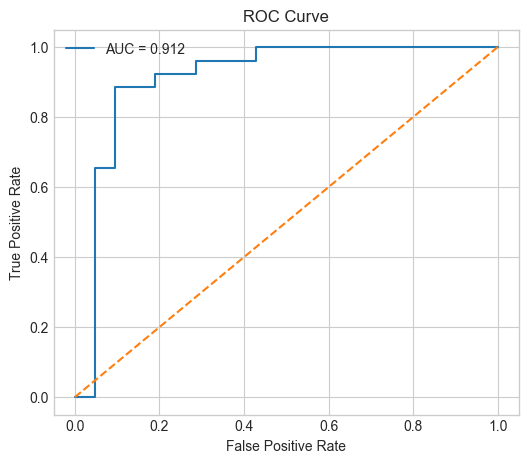

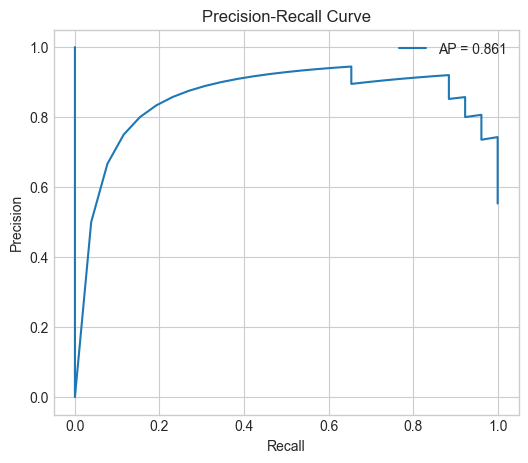

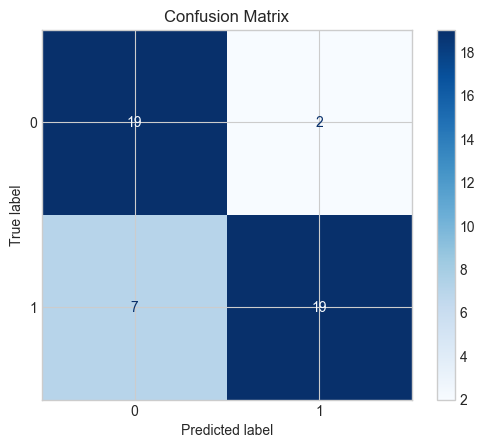

Accuracy: 0.8085106382978723
Precision: 0.9047619047619048
Recall: 0.7307692307692307
ROC-AUC: 0.9120879120879121
PR-AUC: 0.860573326672587
Confusion Matrix:
[[19  2]
 [ 7 19]]


In [56]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train, X_test, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

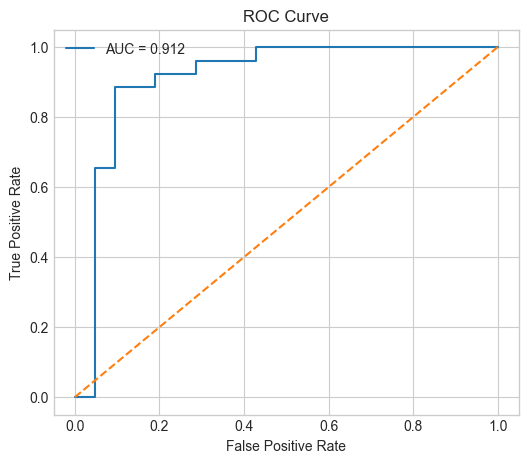

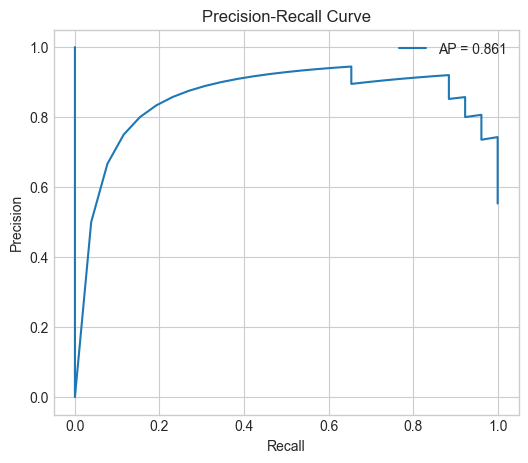

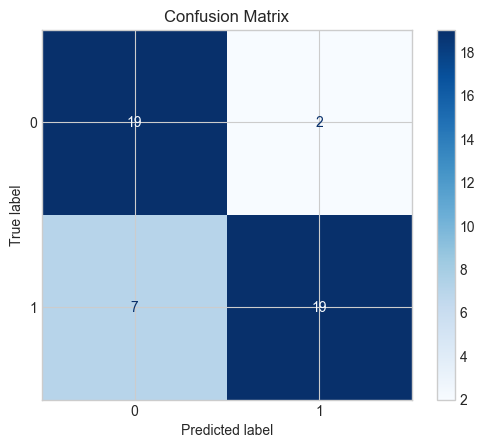

Accuracy: 0.8085106382978723
Precision: 0.9047619047619048
Recall: 0.7307692307692307
ROC-AUC: 0.9120879120879121
PR-AUC: 0.860573326672587
Confusion Matrix:
[[19  2]
 [ 7 19]]


In [57]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

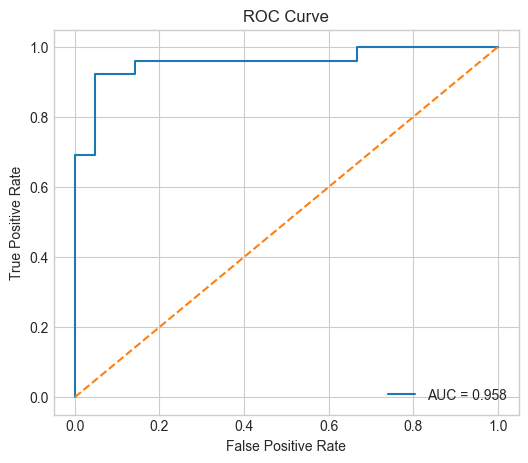

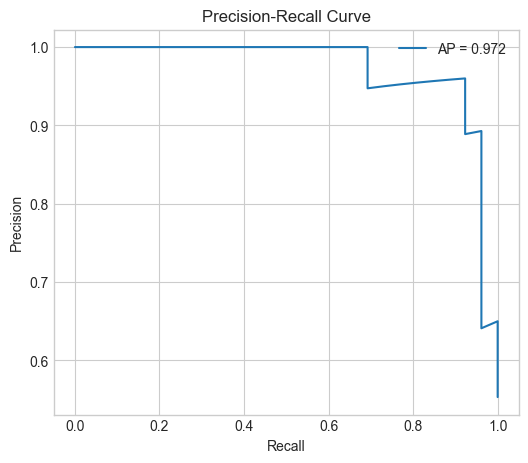

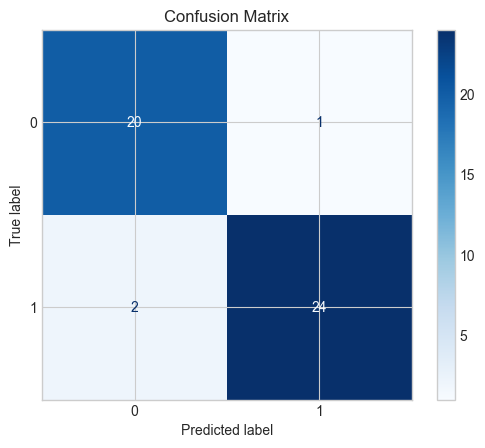

Accuracy: 0.9361702127659575
Precision: 0.96
Recall: 0.9230769230769231
ROC-AUC: 0.9578754578754579
PR-AUC: 0.9721014854710505
Confusion Matrix:
[[20  1]
 [ 2 24]]


In [58]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_mi, X_test_mi, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

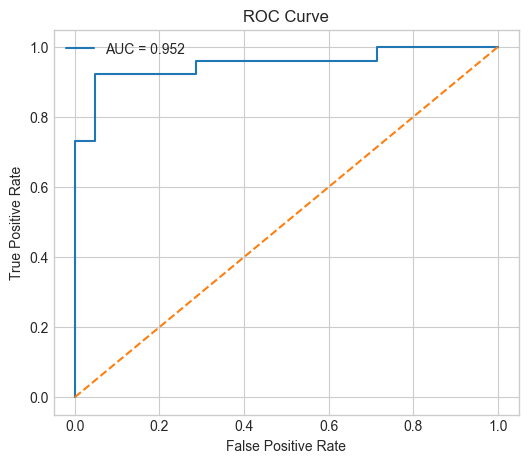

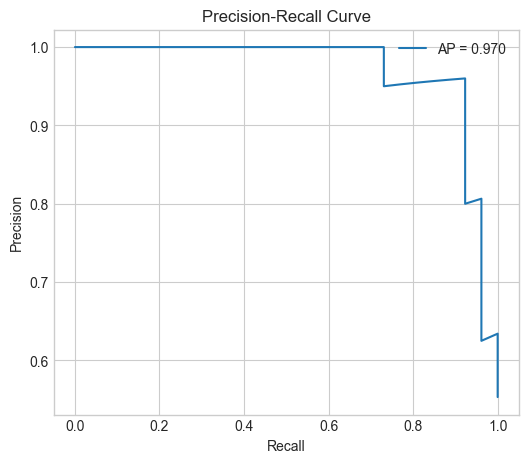

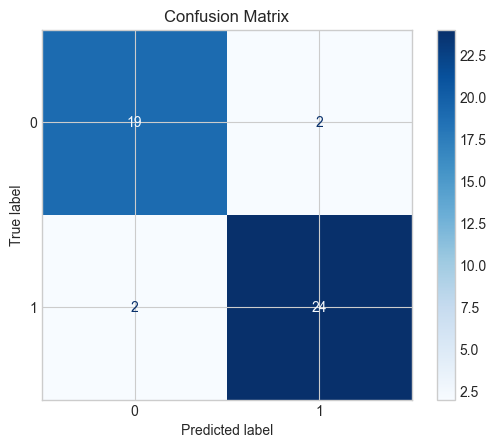

Accuracy: 0.9148936170212766
Precision: 0.9230769230769231
Recall: 0.9230769230769231
ROC-AUC: 0.9523809523809523
PR-AUC: 0.9700915166829543
Confusion Matrix:
[[19  2]
 [ 2 24]]


In [59]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_ttest, X_test_ttest, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

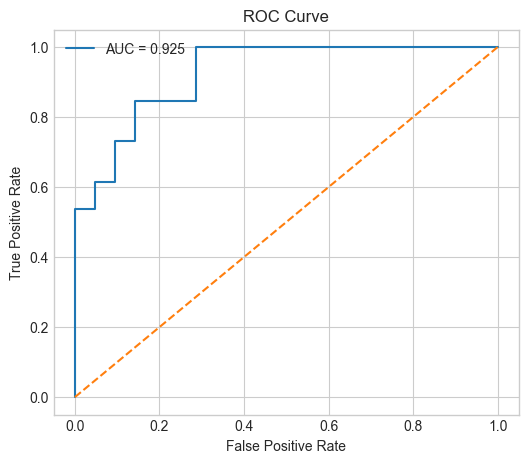

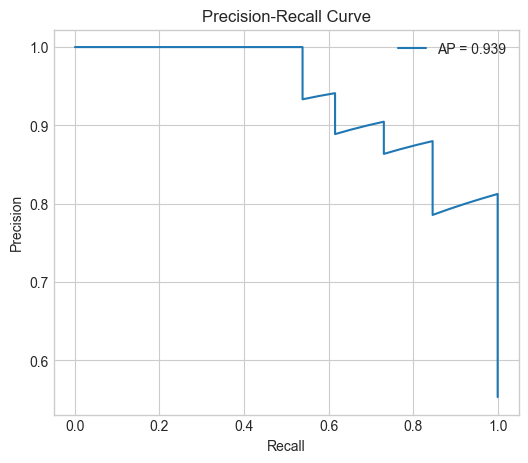

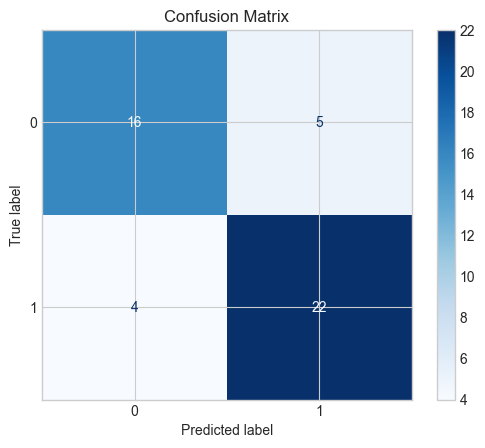

Accuracy: 0.8085106382978723
Precision: 0.8148148148148148
Recall: 0.8461538461538461
ROC-AUC: 0.924908424908425
PR-AUC: 0.939030596000992
Confusion Matrix:
[[16  5]
 [ 4 22]]


In [60]:

acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_chi2, X_test_chi2, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

#### Performance comparison for decession tree

In [61]:
def evaluate_model(X_train, X_test, y_train, y_test):
    
    model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
    )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    
    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

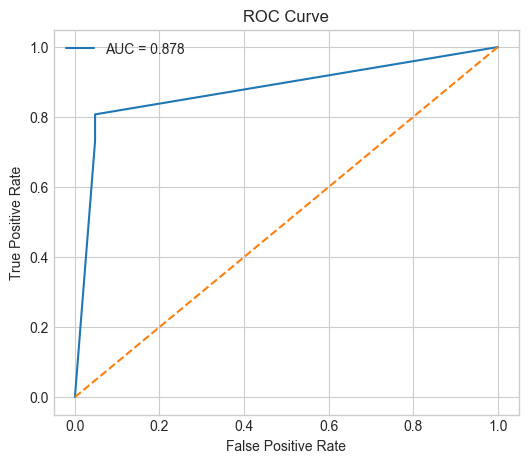

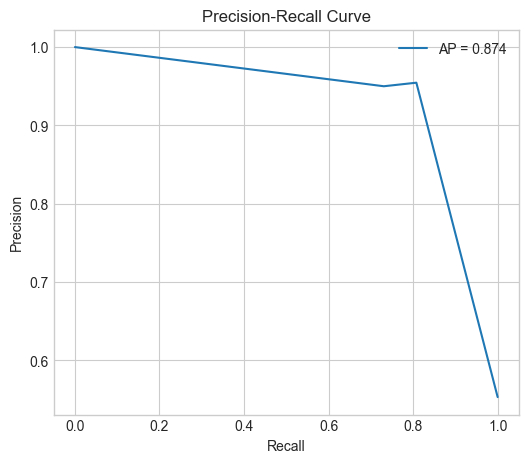

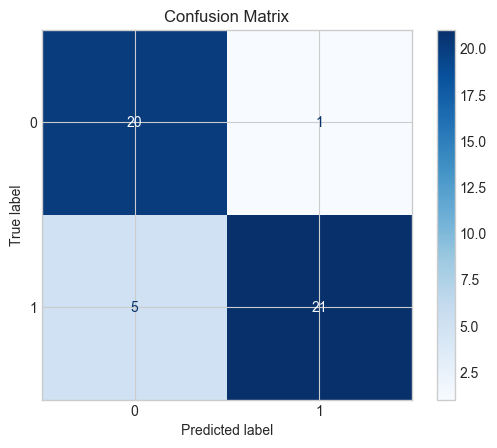

Accuracy: 0.8723404255319149
Precision: 0.9545454545454546
Recall: 0.8076923076923077
ROC-AUC: 0.8782051282051282
PR-AUC: 0.8740403213807469
Confusion Matrix:
[[20  1]
 [ 5 21]]


In [62]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train, X_test, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

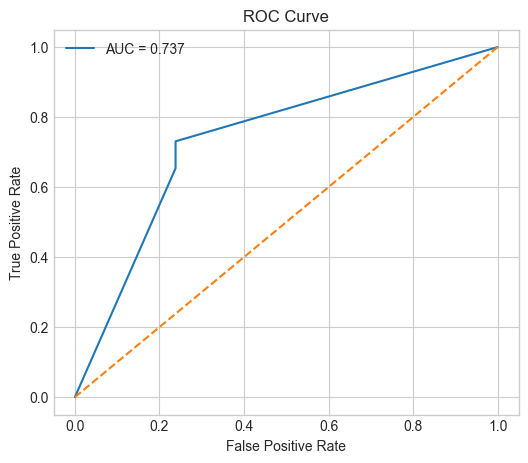

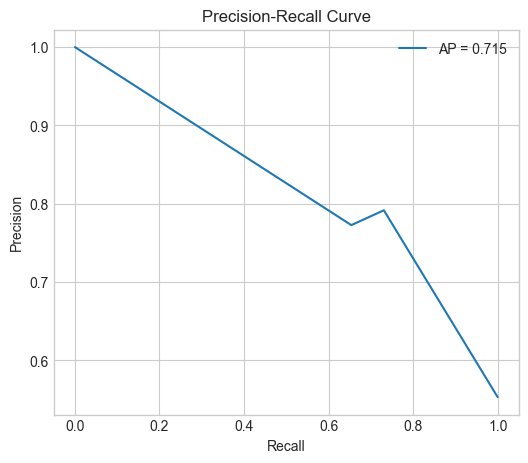

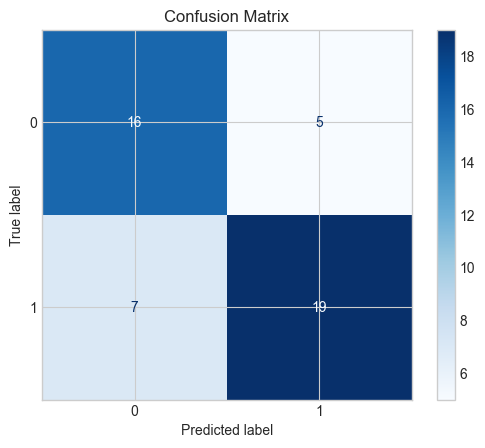

Accuracy: 0.7446808510638298
Precision: 0.7916666666666666
Recall: 0.7307692307692307
ROC-AUC: 0.7371794871794872
PR-AUC: 0.7150783613549571
Confusion Matrix:
[[16  5]
 [ 7 19]]


In [63]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

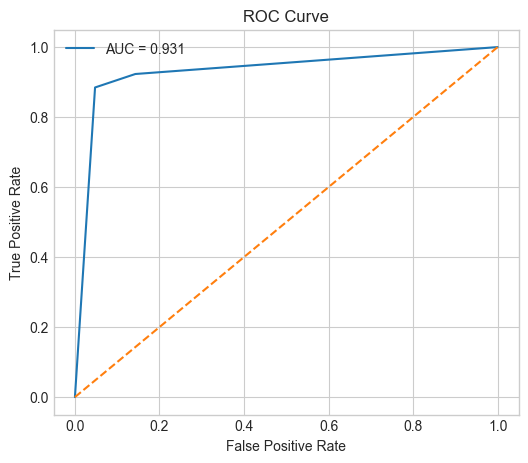

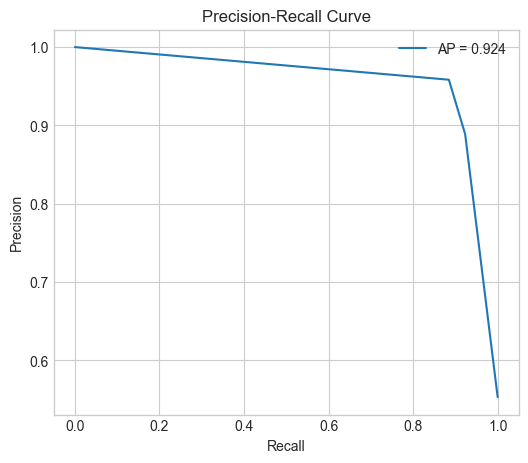

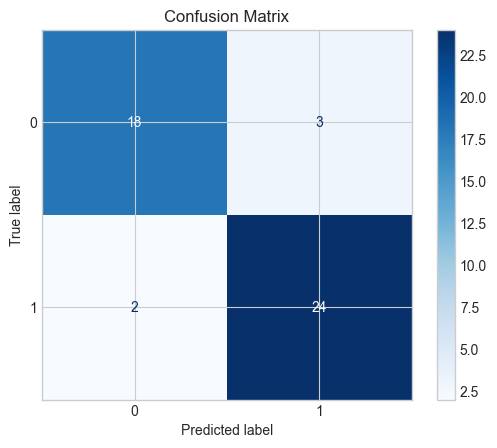

Accuracy: 0.8936170212765957
Precision: 0.8888888888888888
Recall: 0.9230769230769231
ROC-AUC: 0.9313186813186813
PR-AUC: 0.9244976359338062
Confusion Matrix:
[[18  3]
 [ 2 24]]


In [64]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_mi, X_test_mi, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

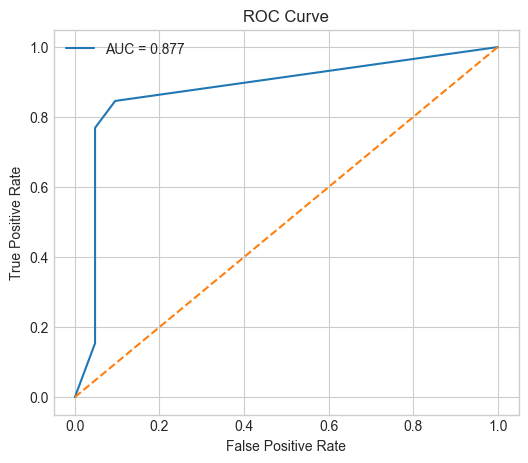

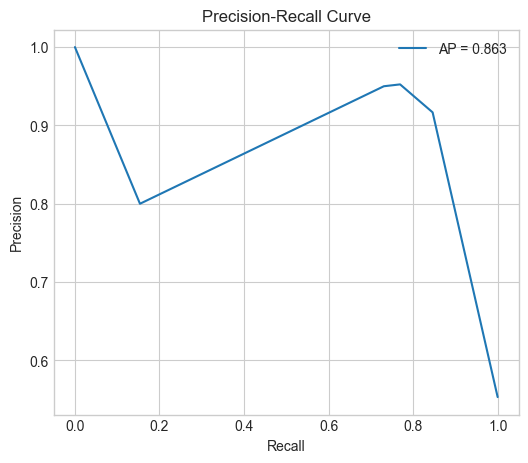

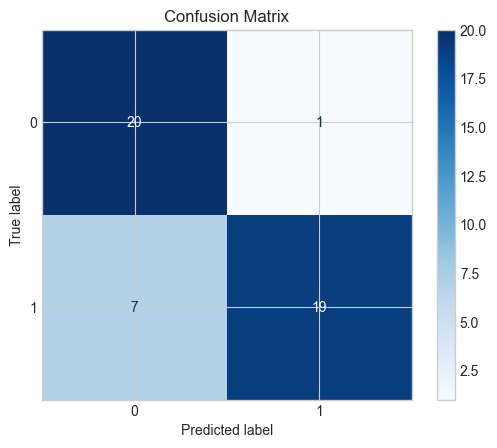

Accuracy: 0.8297872340425532
Precision: 0.95
Recall: 0.7307692307692307
ROC-AUC: 0.8772893772893773
PR-AUC: 0.8634030862754267
Confusion Matrix:
[[20  1]
 [ 7 19]]


In [65]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_ttest, X_test_ttest, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

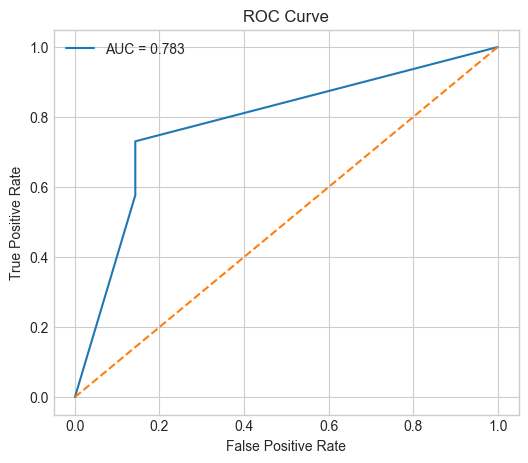

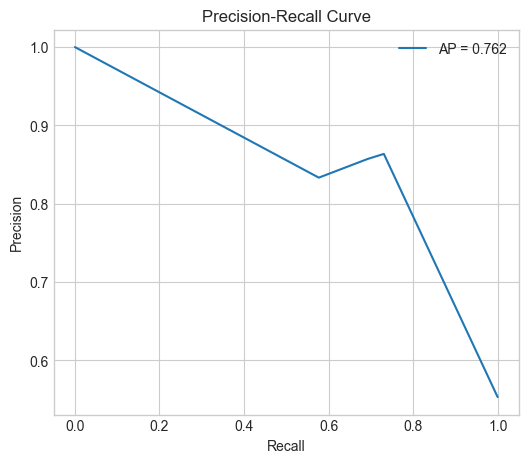

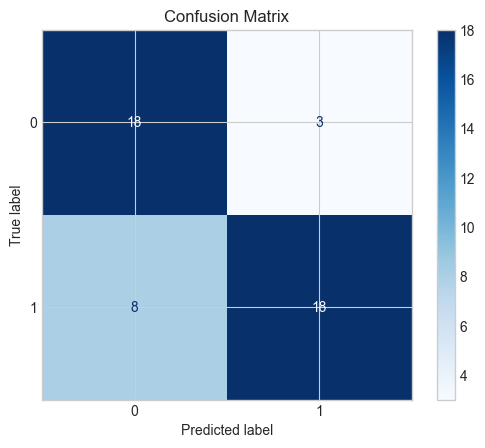

Accuracy: 0.7659574468085106
Precision: 0.8571428571428571
Recall: 0.6923076923076923
ROC-AUC: 0.782967032967033
PR-AUC: 0.7618232830998788
Confusion Matrix:
[[18  3]
 [ 8 18]]


In [66]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_chi2, X_test_chi2, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

#### Performance with Random Forest Classifier

In [67]:
def evaluate_model(X_train, X_test, y_train, y_test):
    
    model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
     )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    
    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

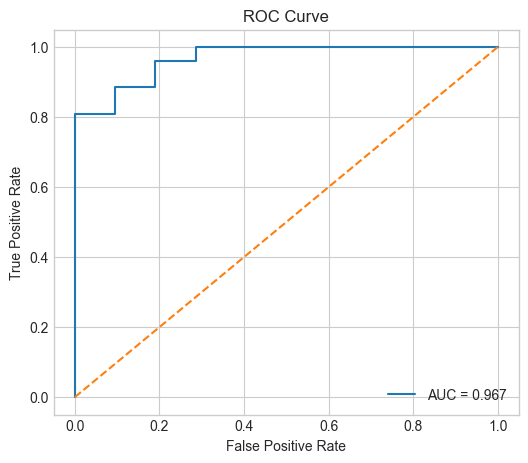

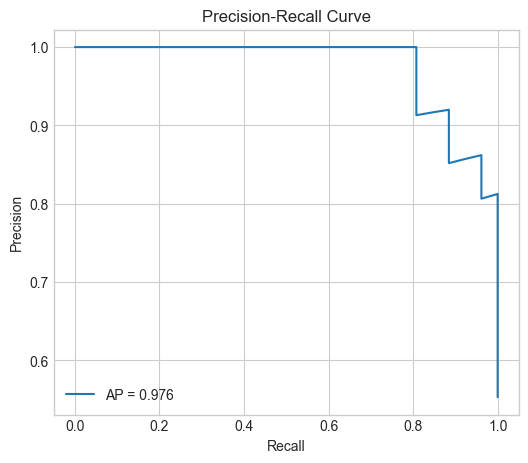

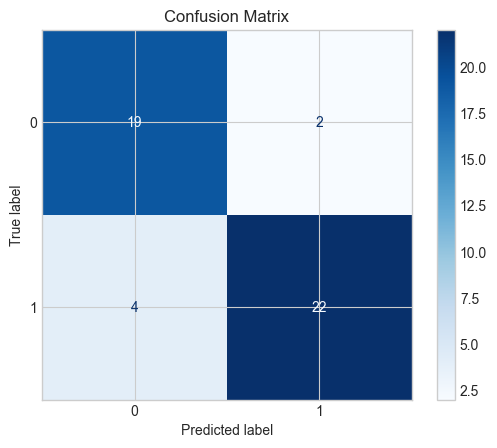

Accuracy: 0.8723404255319149
Precision: 0.9166666666666666
Recall: 0.8461538461538461
ROC-AUC: 0.967032967032967
PR-AUC: 0.9757068649741062
Confusion Matrix:
[[19  2]
 [ 4 22]]


In [68]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train, X_test, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

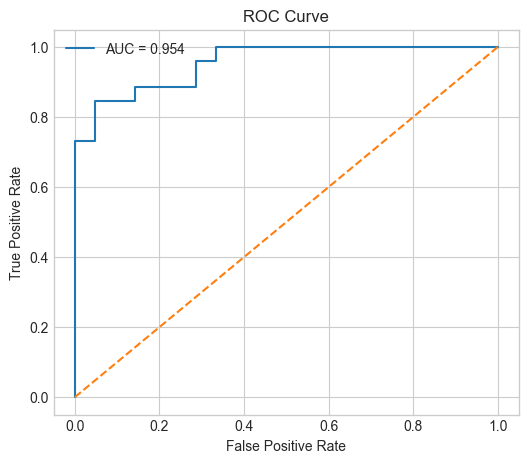

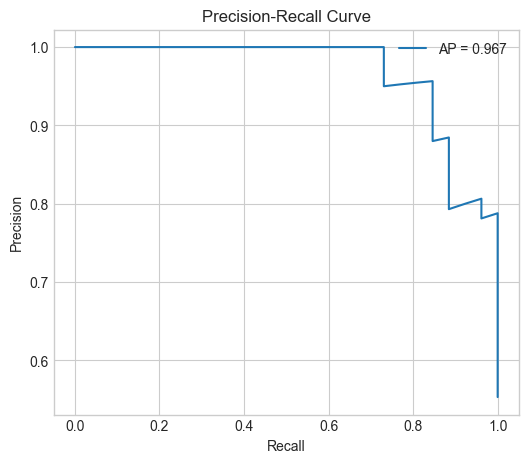

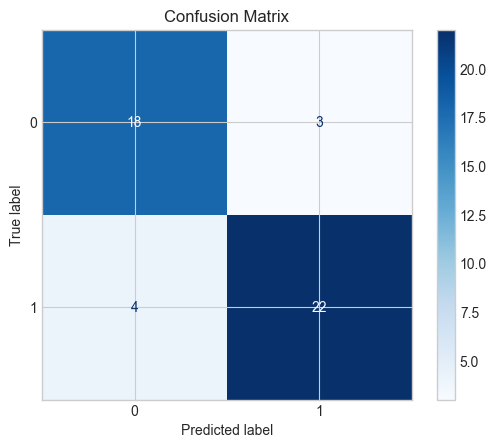

Accuracy: 0.851063829787234
Precision: 0.88
Recall: 0.8461538461538461
ROC-AUC: 0.9542124542124543
PR-AUC: 0.9670151512097783
Confusion Matrix:
[[18  3]
 [ 4 22]]


In [69]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

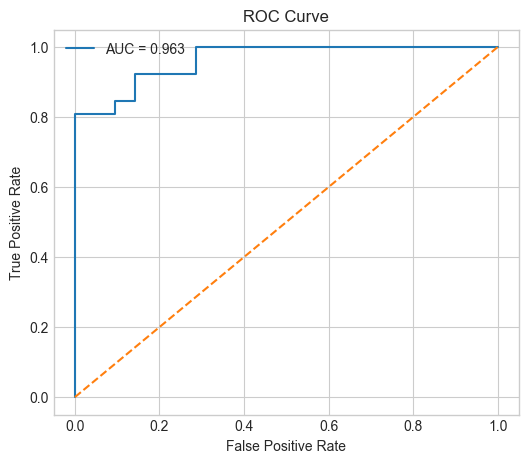

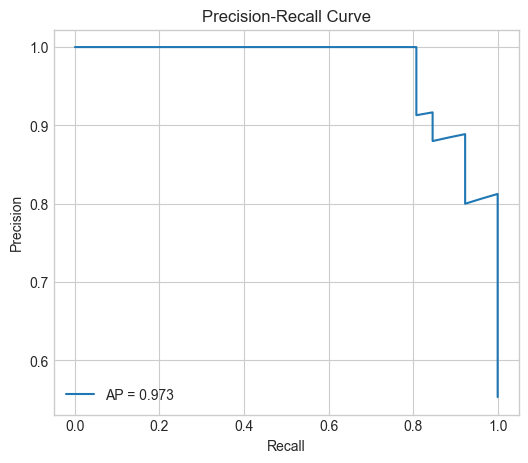

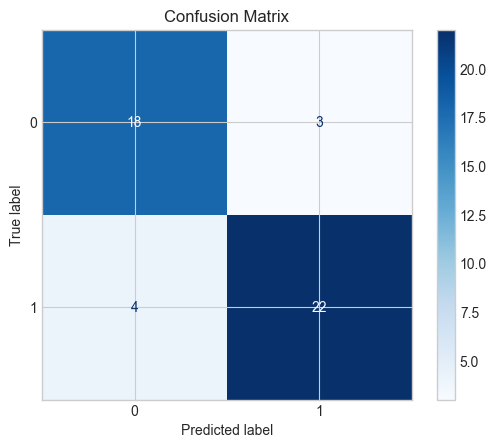

Accuracy: 0.851063829787234
Precision: 0.88
Recall: 0.8461538461538461
ROC-AUC: 0.9633699633699634
PR-AUC: 0.9734277905028523
Confusion Matrix:
[[18  3]
 [ 4 22]]


In [70]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_mi, X_test_mi, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

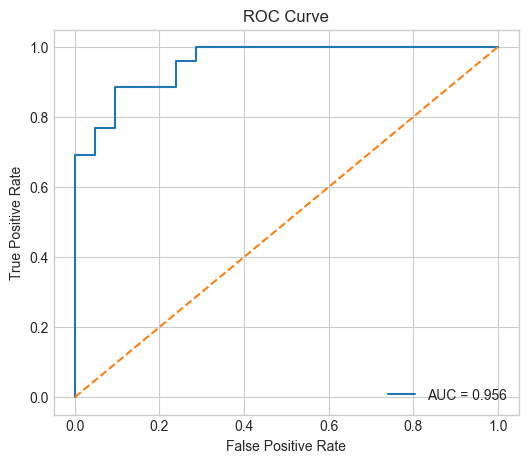

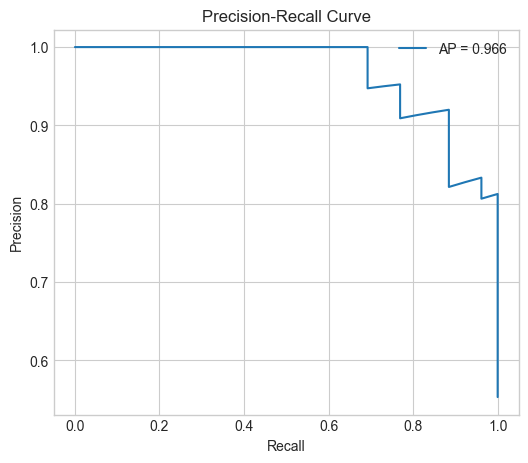

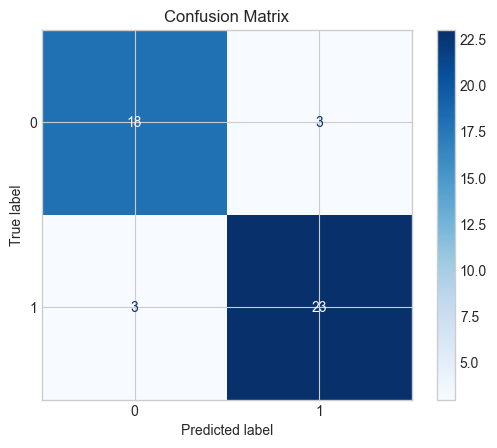

Accuracy: 0.8723404255319149
Precision: 0.8846153846153846
Recall: 0.8846153846153846
ROC-AUC: 0.9560439560439561
PR-AUC: 0.9663657937514757
Confusion Matrix:
[[18  3]
 [ 3 23]]


In [71]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_ttest, X_test_ttest, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

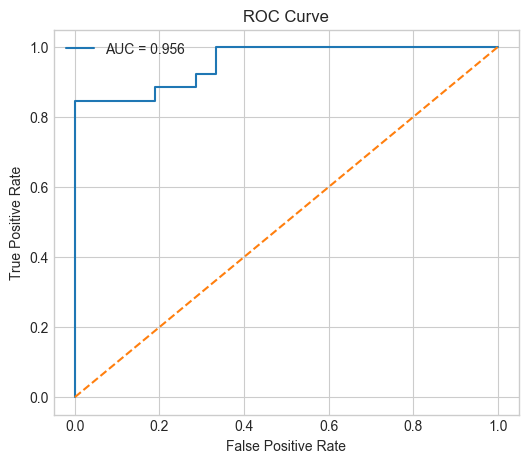

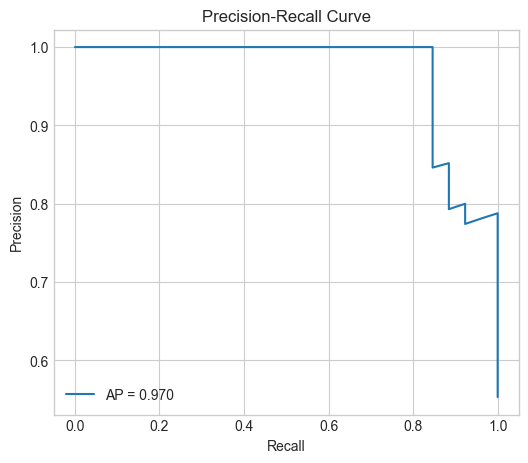

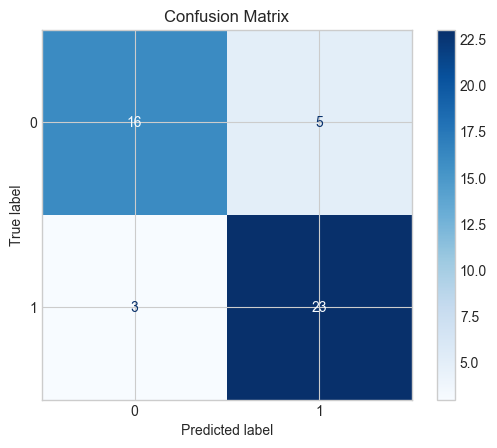

Accuracy: 0.8297872340425532
Precision: 0.8214285714285714
Recall: 0.8846153846153846
ROC-AUC: 0.956043956043956
PR-AUC: 0.9700377169127167
Confusion Matrix:
[[16  5]
 [ 3 23]]


In [72]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_chi2, X_test_chi2, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

### performance with SVM

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
from sklearn.svm import SVC

def evaluate_model(X_train, X_test, y_train, y_test):
    
    model = SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        probability=True,
        random_state=42
        )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    
    # ---------------- ROC Curve ----------------
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # ---------------- PR Curve ----------------
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

    return acc, prec, rec, roc_auc, pr_auc, cm

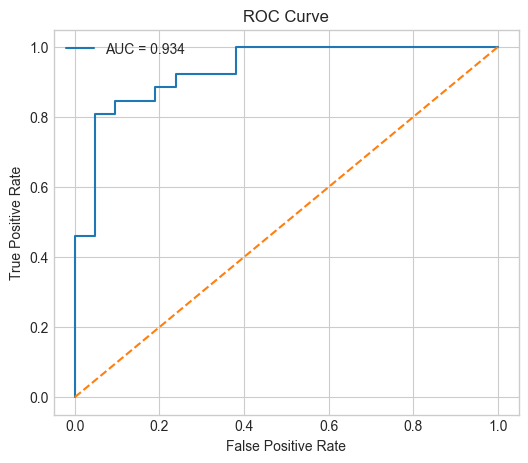

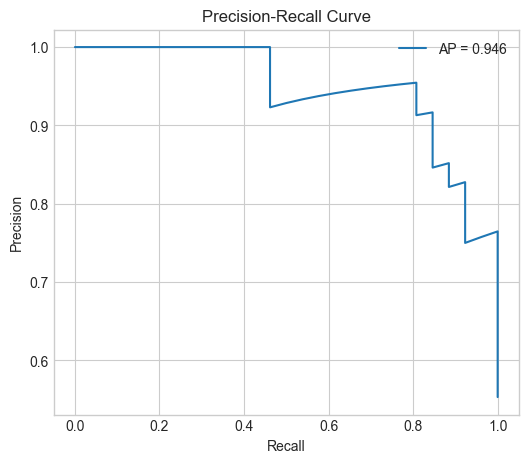

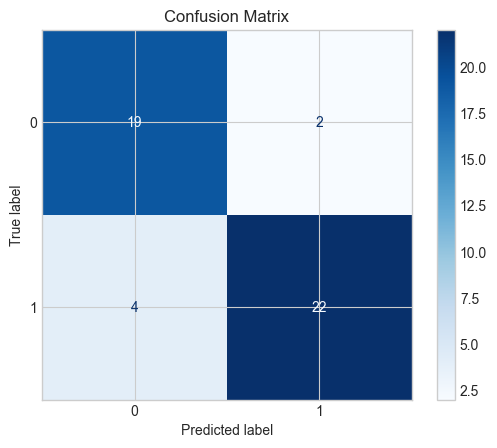

Accuracy: 0.8723404255319149
Precision: 0.9166666666666666
Recall: 0.8461538461538461
ROC-AUC: 0.9340659340659341
PR-AUC: 0.9464502642407787
Confusion Matrix:
[[19  2]
 [ 4 22]]


In [75]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train, X_test, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

In [76]:
scaler = StandardScaler()

X_train_var = scaler.fit_transform(X_train_var)
X_test_var = scaler.transform(X_test_var)

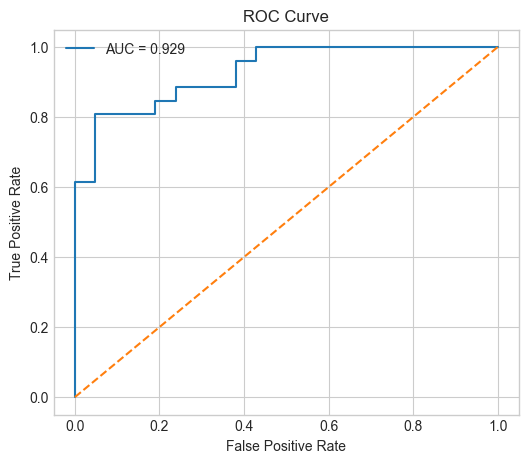

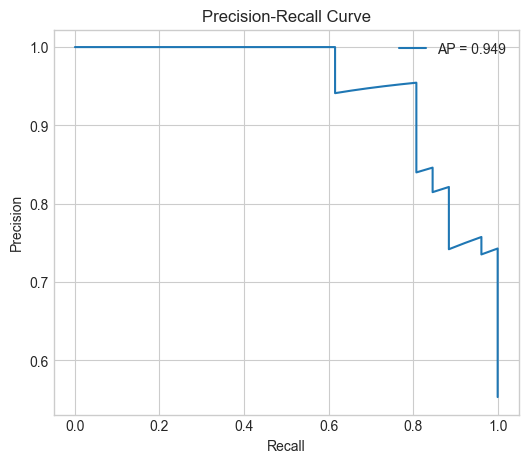

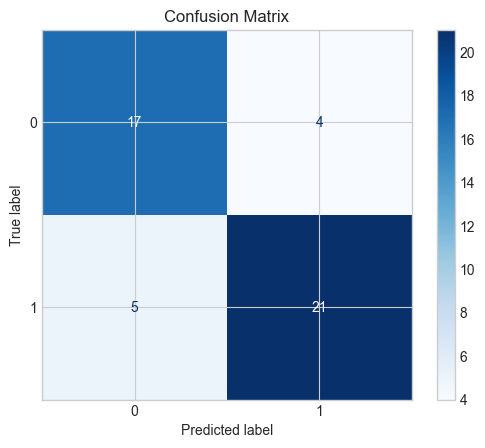

Accuracy: 0.8085106382978723
Precision: 0.84
Recall: 0.8076923076923077
ROC-AUC: 0.9285714285714286
PR-AUC: 0.9487213304014922
Confusion Matrix:
[[17  4]
 [ 5 21]]


In [77]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_var, X_test_var, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

In [78]:
X_train_mi = scaler.fit_transform(X_train_mi)
X_test_mi = scaler.transform(X_test_mi)

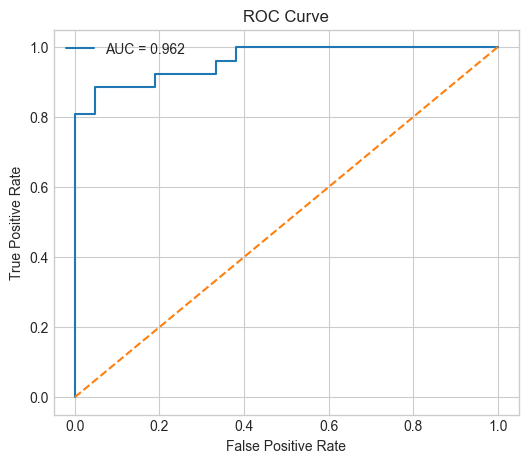

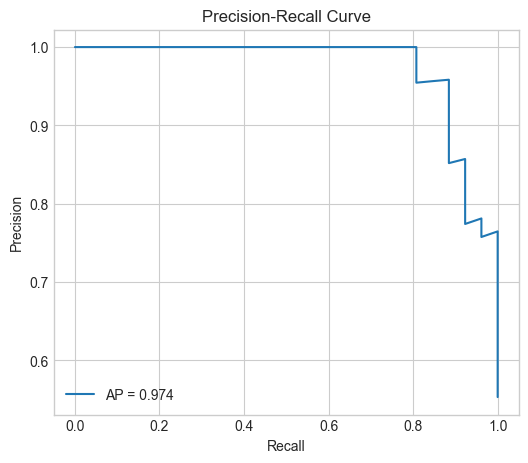

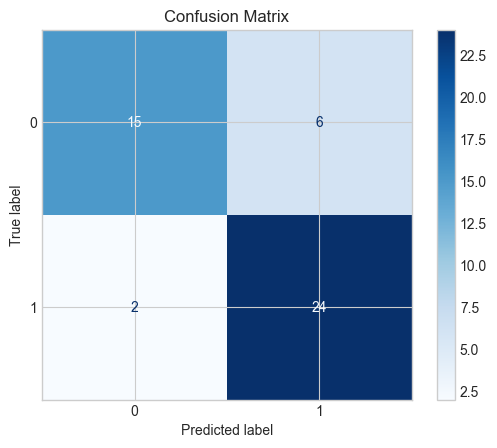

Accuracy: 0.8297872340425532
Precision: 0.8
Recall: 0.9230769230769231
ROC-AUC: 0.9615384615384615
PR-AUC: 0.973767454306137
Confusion Matrix:
[[15  6]
 [ 2 24]]


In [79]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_mi, X_test_mi, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

In [80]:
X_train_chi2 = scaler.fit_transform(X_train_chi2)
X_test_chi2 = scaler.transform(X_test_chi2)

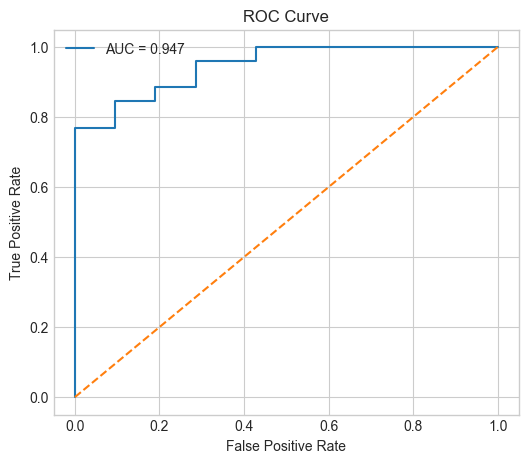

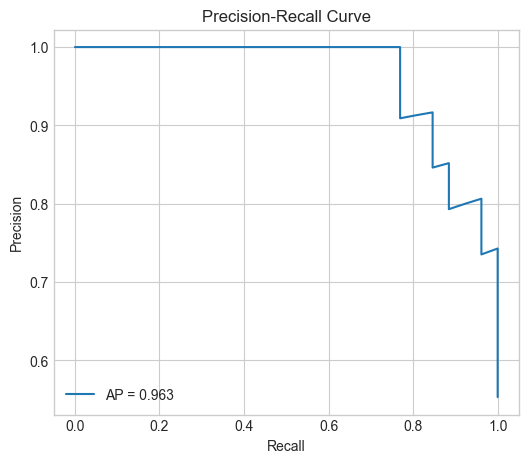

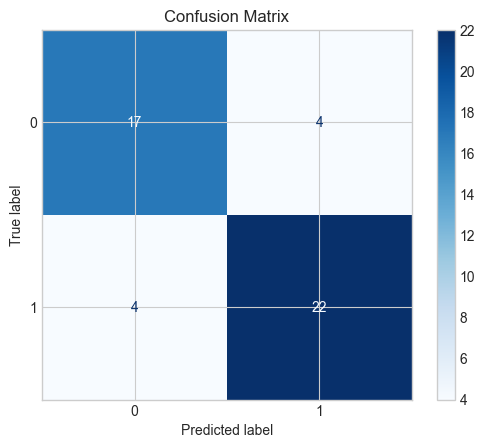

Accuracy: 0.8297872340425532
Precision: 0.8461538461538461
Recall: 0.8461538461538461
ROC-AUC: 0.9468864468864469
PR-AUC: 0.9627257981746059
Confusion Matrix:
[[17  4]
 [ 4 22]]


In [81]:
acc, prec, rec, roc_auc, pr_auc, cm = evaluate_model(
    X_train_chi2, X_test_chi2, y_train, y_test
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("Confusion Matrix:")
print(cm)

## Part 4: Unsupervised Learning

In [82]:
df_cluster = df_merged.copy()

In [83]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 169
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Alcoholic Beverages       154 non-null    float64
 1   Animal Products           154 non-null    float64
 2   Animal fats               154 non-null    float64
 3   Aquatic Products, Other   154 non-null    float64
 4   Cereals - Excluding Beer  154 non-null    float64
 5   Eggs                      154 non-null    float64
 6   Fish, Seafood             154 non-null    float64
 7   Fruits - Excluding Wine   154 non-null    float64
 8   Meat                      154 non-null    float64
 9   Milk - Excluding Butter   154 non-null    float64
 10  Miscellaneous             154 non-null    float64
 11  Offals                    154 non-null    float64
 12  Oilcrops                  154 non-null    float64
 13  Pulses                    154 non-null    float64
 14  Spices         

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster)

### K-means clustering 

#### Elbow Method to Choose K

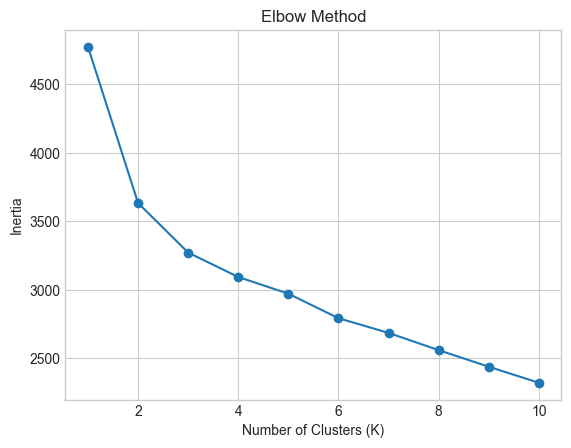

In [85]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Silhouette Score

In [86]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"K={k}, Silhouette={score:.3f}")

K=2, Silhouette=0.212
K=3, Silhouette=0.144
K=4, Silhouette=0.142
K=5, Silhouette=0.113
K=6, Silhouette=0.150
K=7, Silhouette=0.109
K=8, Silhouette=0.122
K=9, Silhouette=0.109
K=10, Silhouette=0.123


### Final KMeans Fit

In [87]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df_cluster['Cluster'] = clusters

### Hierarchical Clustering

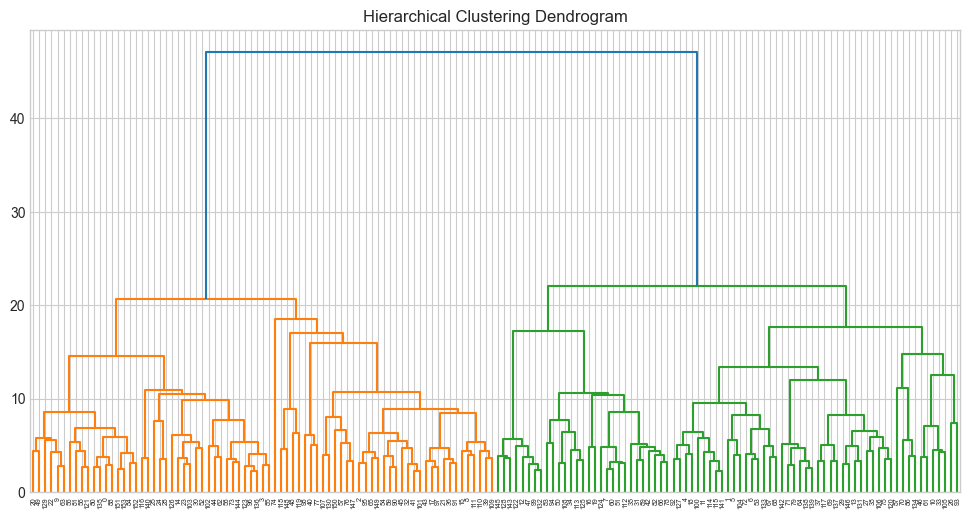

In [88]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

### DBSCAN

In [89]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

print(set(db_labels))

{np.int64(-1)}


### Visualize Clusters Using PCA

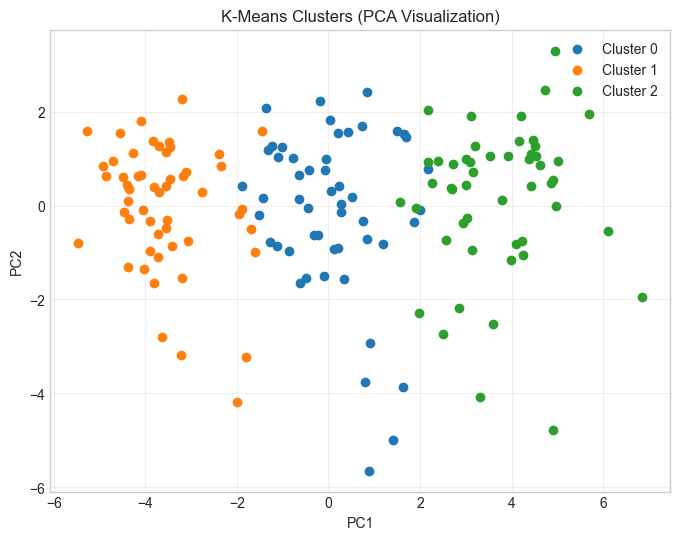

In [90]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Unique cluster labels
unique_clusters = np.unique(clusters)

plt.figure(figsize=(8,6))

# Plot each cluster separately
for cluster in unique_clusters:
    
    idx = clusters == cluster
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Visualization)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Part 5: Dimensionality Reduction

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% variance

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 29
Reduced features: 19


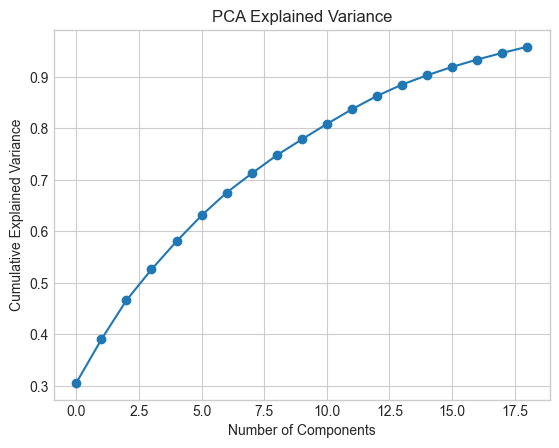

In [93]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

### Part 6: Experimental Design & Analysis

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [95]:
from sklearn.metrics import accuracy_score

def evaluate(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    return accuracy_score(y_test, pred)

In [96]:
results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),
    
    "SVM": SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        random_state=42
    )
}

for name, model in models.items():
    
    # Original Features
    acc_orig = evaluate(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
    
    # PCA Features
    acc_pca = evaluate(
        model,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test
    )
    
    results.append([name, acc_orig, acc_pca])

In [97]:
import pandas as pd

df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy (Original)", "Accuracy (PCA)"]
)

print(df_results)

                 Model  Accuracy (Original)  Accuracy (PCA)
0  Logistic Regression             0.808511        0.787234
1        Random Forest             0.872340        0.808511
2                  SVM             0.872340        0.851064


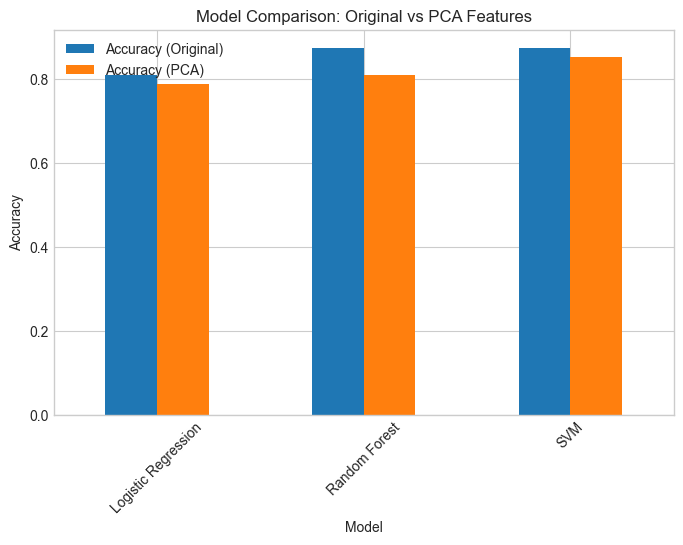

In [98]:
import matplotlib.pyplot as plt

df_results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.ylabel("Accuracy")
plt.title("Model Comparison: Original vs PCA Features")

plt.xticks(rotation=45)

plt.show()